In [ ]:
# IMPORT LIBRARIES

import numpy as np                    # For mathematical arrays and operations
from scipy.special import expi        # The Ei(-x) function — the CORE of well testing
import matplotlib.pyplot as plt       # For plotting type curves
import pandas as pd                   # For organizing data in tables
import os                             # For creating folders to save files

# Create output folders
os.makedirs('output/curves',   exist_ok=True)
os.makedirs('output/datasets', exist_ok=True)
os.makedirs('output/figures',  exist_ok=True)

print('All libraries loaded successfully!')


All libraries loaded successfully!


# **Defining the Ei(-x) Pressure Function**

In [ ]:
#Core pressure function using Ei(-x)

def compute_delta_P_isotropic(r_ft, t_hr, q, B, mu, k, h, phi, ct):
    """
    Compute pressure drop at distance r from a well producing at rate q.
    All inputs in field units (ft, hours, STB/day, RB/STB, cp, md, ft, fraction, 1/psi)
    Returns pressure drop in psi.
    """
    # The argument of the Ei function
    x = (948.0 * phi * mu * ct * r_ft**2) / (k * t_hr)

    # Ei(-x) using scipy — returns Ei(x), so we use expi(-x)
    # Note: expi returns NaN for x=0, so we handle the case x < 1e-10
    x = np.where(x < 1e-10, 1e-10, x)   # Avoid division by zero

    # Pressure drop formula from class (field units)
    delta_P = (70.6 * q * B * mu) / (k * h) * (-expi(-x))

    return delta_P

# Quick test: does this give a reasonable answer?
test_dP = compute_delta_P_isotropic(
    r_ft=1020,    # ft from the well
    t_hr=240,    # After days converted to hours
    q=200,       # STB/day production
    B=1.32,      # Formation volume factor
    mu=0.44,     # Oil viscosity (cp)
    k=50,        # Permeability (md)
    h=70,        # Net pay (ft)
    phi=0.20,    # Porosity
    ct=2e-6     # Total compressibility (1/psi)
)
print(f'Pressure drop at 1020 ft after 240 hrs: {test_dP:.2f} psi')


Pressure drop at 1020 ft after 240 hrs: 8.61 psi


# **Convert to Dimensionless Variables (PD and tD/rD²)**

In [ ]:
def to_dimensionless(delta_P, t_hr, r_ft, q, B, mu, k, h, phi, ct, rw=0.25):
    """
    Convert pressure drop and time to dimensionless PD and tD/rD².
    rw = wellbore radius in feet (default 0.3 ft)
    """
    # Dimensionless pressure
    PD = (k * h * delta_P) / (141.2 * q * B * mu)

    # Dimensionless time
    tD = (0.0002637 * k * t_hr) / (mu * phi * ct * rw**2)

    # Dimensionless distance
    rD = r_ft / rw

    # The combined parameter for type curves
    tD_over_rD2 = tD / (rD**2)

    return PD, tD_over_rD2

# Test it
PD_test, tDrD2_test = to_dimensionless(
    delta_P=test_dP, t_hr=240, r_ft=1020,
    q=200, B=1.32, mu=0.44, k=50, h=70, phi=0.20, ct=2e-6
)
print(f'PD = {PD_test:.4f},  tD/rD² = {tDrD2_test:.6f}')


PD = 1.8366,  tD/rD² = 17.281378


## **Anisotropic Pressure Function**:
*   kr replaces k in the Ei argument
*   ke replaces k in the amplitude.

In [ ]:
def compute_delta_P_anisotropic(X_ft, Y_ft, t_hr, q, B, mu,
                                 Kmax, Kmin, alpha_deg, h, phi, ct):
    """
    Compute pressure drop in an anisotropic reservoir.
    X_ft, Y_ft: observation well position in GLOBAL coordinates (x-axis = north/reference)
    alpha_deg:  orientation of Kmax from x-axis in degrees
    All other units same as isotropic function.
    """
    # Step 1: Equivalent isotropic permeability
    Ke = np.sqrt(Kmax * Kmin)

    # Step 2: Distance from active to observation well
    r = np.sqrt(X_ft**2 + Y_ft**2)
    r = np.where(r < 0.001, 0.001, r)  # Avoid zero

    # Step 3: Radial directional permeability (Kr)
    theta_abs = np.arctan2(Y_ft, X_ft)              # angle of obs well from x-axis
    theta_rel = theta_abs - np.radians(alpha_deg)   # angle of obs well FROM Kmax axis
    Kr = 1.0 / (np.cos(theta_rel)**2 / Kmax + np.sin(theta_rel)**2 / Kmin)

    # Step 4: Ei function argument (uses Kr instead of k)
    x = (948.0 * phi * mu * ct * r**2) / (Kr * t_hr)
    x = np.where(x < 1e-10, 1e-10, x)

    # Step 5: Pressure drop (uses Ke in amplitude instead of k)
    delta_P = (70.6 * q * B * mu) / (Ke * h) * (-expi(-x))

    return delta_P, Ke, Kr

# Test: anisotropic case should give DIFFERENT answer than isotropic
# even at same total distance, if observation well is not on principal axis
dP_aniso, Ke_test, Kr_test = compute_delta_P_anisotropic(
    X_ft=1000, Y_ft=200,    # 500 ft away, at 45 degrees from Kmax axis
    t_hr=240, q=200, B=1.32, mu=0.44,
    Kmax=50, Kmin=10,       # Anisotropy ratio = 5
    alpha_deg=90,            # Kmax along x-axis
    h=70, phi=0.2, ct=2e-6
)
print(f'Anisotropic ΔP: {dP_aniso:.2f} psi')
print(f'Ke = {Ke_test:.2f} md,  Kr = {Kr_test:.2f} md')
print(f'Ke/Kr ratio: {Ke_test/Kr_test:.3f}')

Anisotropic ΔP: 11.26 psi
Ke = 22.36 md,  Kr = 10.32 md
Ke/Kr ratio: 2.167


# **Adding Boundary Effects (Image Wells)**

*   For a no-flow boundary, add an image producer
*   For constant pressure, add an image injector (negative rate)



In [ ]:
def compute_delta_P_with_boundary(
        X_obs, Y_obs, t_hr,        # Observation well position and time
        X_active, Y_active,        # Active well position (usually 0,0)
        boundary_type,             # 'none', 'no_flow', 'const_pressure'
        boundary_dist_ft,          # Distance from active well to boundary (ft)
        boundary_angle_deg,        # Angle of boundary normal from x-axis (degrees)
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct):
    """
    Compute pressure drop including boundary effect.
    The boundary is a straight line at distance boundary_dist_ft from the active well,
    perpendicular to the direction given by boundary_angle_deg.
    """
    # Pressure from the real active well at observation well location
    dP_real, _, _ = compute_delta_P_anisotropic(
        X_obs - X_active, Y_obs - Y_active, t_hr,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)

    if boundary_type == 'none':
        return dP_real

    # --- Locate image well ---
    # The image well is the mirror of the active well across the boundary
    angle_rad = np.radians(boundary_angle_deg)
    # Normal vector pointing toward boundary
    nx, ny = np.cos(angle_rad), np.sin(angle_rad)
    # Image well is at 2 × boundary_dist in the normal direction
    X_image = X_active + 2.0 * boundary_dist_ft * nx
    Y_image = Y_active + 2.0 * boundary_dist_ft * ny

    # Pressure from image well at observation well
    # No-flow: image is a PRODUCER (same sign as real well, q_image = +q)
    # Const pressure: image is an INJECTOR (opposite sign, q_image = -q)
    q_image = q if boundary_type == 'no_flow' else -q

    dP_image, _, _ = compute_delta_P_anisotropic(
        X_obs - X_image, Y_obs - Y_image, t_hr,
        q_image, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)

    # Superposition: total pressure = real + image
    dP_total = dP_real + dP_image
    return dP_total

print('Boundary function defined successfully')


Boundary function defined successfully


In [ ]:
print(compute_delta_P_with_boundary)

<function compute_delta_P_with_boundary at 0x7c70294d5800>


# **One Complete Type Curve Plot**

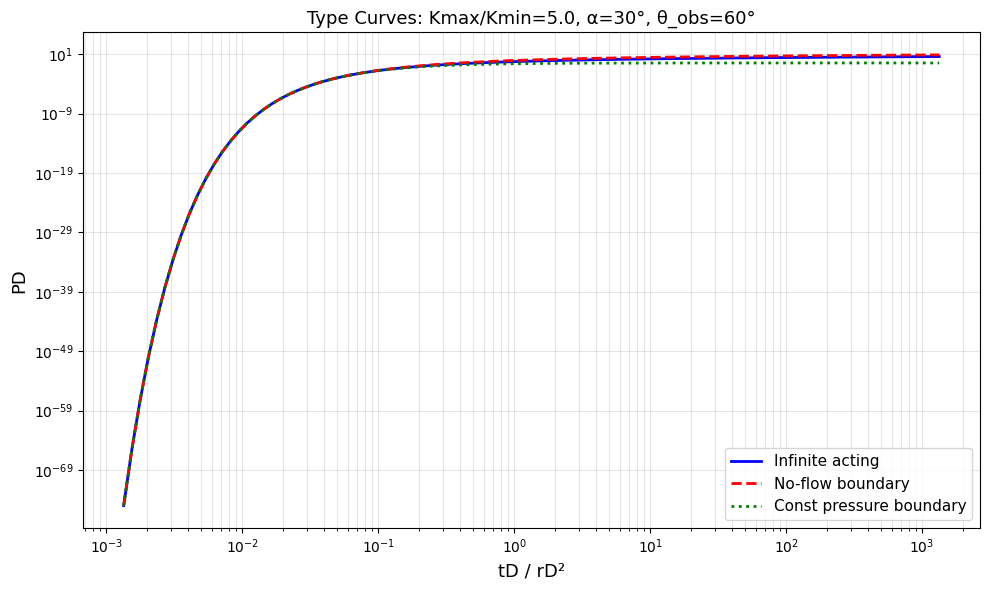

Your first type curve has been saved!


In [ ]:

q=200; B=1.32; mu=0.44; h=70; phi=0.2; ct=2e-6; rw=0.25
r_obs = 500           # Observation well at 500 ft
theta_obs_deg = 60    # Observation well is 30 degrees from Kmax axis

# --- Anisotropy case ---
Kmax = 50.0           # md
Kmin = 10.0           # md  → Kmax/Kmin = 5
alpha_deg = 30          # Kmax along x-axis

# Observation well position in principal coordinates

theta_obs_rad = np.radians(theta_obs_deg)
X_obs = r_obs * np.cos(theta_obs_rad)
Y_obs = r_obs * np.sin(theta_obs_rad)

# --- Time array: 100 log-spaced points from 0.01 to 10000 hours ---
t_array = np.logspace(-2, 4, 100)

# --- Compute pressure drop at each time ---
dP_infinite  = []   # No boundary
dP_no_flow   = []   # No-flow boundary at 1000 ft
dP_const_P   = []   # Constant pressure boundary at 1000 ft

for t in t_array:
    dP_inf = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0, 'none', 400, 90,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)
    dP_nf = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0, 'no_flow', 400, 90,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)
    dP_cp = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0, 'const_pressure', 400, 90,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)
    dP_infinite.append(dP_inf)
    dP_no_flow.append(dP_nf)
    dP_const_P.append(dP_cp)

# Convert to numpy arrays
dP_infinite = np.array(dP_infinite)
dP_no_flow  = np.array(dP_no_flow)
dP_const_P  = np.array(dP_const_P)

# Convert to dimensionless PD and tD/rD²
Ke = np.sqrt(Kmax * Kmin)
PD_inf,  tDrD2 = to_dimensionless(dP_infinite, t_array, r_obs, q, B, mu, Ke, h, phi, ct)
PD_nf,   _     = to_dimensionless(dP_no_flow,  t_array, r_obs, q, B, mu, Ke, h, phi, ct)
PD_cp,   _     = to_dimensionless(dP_const_P,  t_array, r_obs, q, B, mu, Ke, h, phi, ct)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(tDrD2, PD_inf, 'b-',  linewidth=2, label='Infinite acting')
ax.loglog(tDrD2, PD_nf,  'r--', linewidth=2, label='No-flow boundary')
ax.loglog(tDrD2, PD_cp,  'g:',  linewidth=2, label='Const pressure boundary')
ax.set_xlabel('tD / rD²',   fontsize=13)
ax.set_ylabel('PD',          fontsize=13)
ax.set_title(f'Type Curves: Kmax/Kmin={Kmax/Kmin}, α={alpha_deg}°, θ_obs={theta_obs_deg}°', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/first_type_curve.png', dpi=150)
plt.show()
print('Your first type curve has been saved!')



## **As the breakout no con clear, maka reduce the boundary distance small fes see wetin go xup.. oh chim: laugh:: .. laughs in discombobulation**

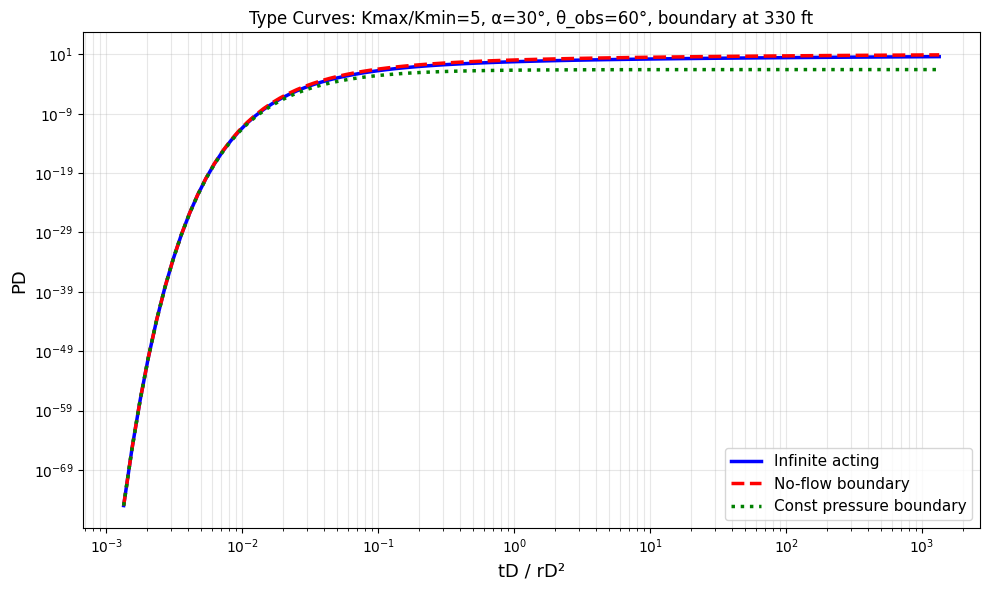

Obs well:    X=250,  Y=433 ft
Image well:  X=0,  Y=660 ft
Obs → image distance: 338 ft  (should be ~300 ft for clear separation)


In [ ]:

# --- Fixed reservoir parameters ---
q=200; B=1.32; mu=0.44; h=70; phi=0.2; ct=2e-6; rw=0.25

# --- Geometry: obs well directly between active well and boundary ---
r_obs        = 500     # obs well at 500 ft from active well
boundary_dist = 330    # boundary at 800 ft — only 300 ft past the obs well
boundary_angle = 90     # boundary is perpendicular to the x-axis (to the right)

# --- Obs well placed along the x-axis — directly toward the boundary ---
theta_obs_deg = 60      # obs well on the x-axis
alpha_deg     = 30      # Kmax also along x-axis

X_obs = r_obs * np.cos(np.radians(theta_obs_deg))   # = 500
Y_obs = r_obs * np.sin(np.radians(theta_obs_deg))   # = 0

# --- Anisotropy ---
Kmax = 50.0
Kmin = 10.0
Ke   = np.sqrt(Kmax * Kmin)

# --- Time array ---
t_array = np.logspace(-2, 4, 100)

# --- Compute pressure drop at each time ---
dP_infinite = []
dP_no_flow  = []
dP_const_P  = []

for t in t_array:
    dP_inf = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0,
        'none', boundary_dist, boundary_angle,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)
    dP_nf = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0,
        'no_flow', boundary_dist, boundary_angle,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)
    dP_cp = compute_delta_P_with_boundary(
        X_obs, Y_obs, t, 0, 0,
        'const_pressure', boundary_dist, boundary_angle,
        q, B, mu, Kmax, Kmin, alpha_deg, h, phi, ct)

    dP_infinite.append(dP_inf)
    dP_no_flow.append(dP_nf)
    dP_const_P.append(dP_cp)

dP_infinite = np.array(dP_infinite)
dP_no_flow  = np.array(dP_no_flow)
dP_const_P  = np.array(dP_const_P)

# --- Convert to dimensionless ---
PD_inf, tDrD2 = to_dimensionless(dP_infinite, t_array, r_obs, q, B, mu, Ke, h, phi, ct)
PD_nf,  _     = to_dimensionless(dP_no_flow,  t_array, r_obs, q, B, mu, Ke, h, phi, ct)
PD_cp,  _     = to_dimensionless(dP_const_P,  t_array, r_obs, q, B, mu, Ke, h, phi, ct)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(tDrD2, PD_inf, 'b-',  linewidth=2.5, label='Infinite acting')
ax.loglog(tDrD2, PD_nf,  'r--', linewidth=2.5, label='No-flow boundary')
ax.loglog(tDrD2, PD_cp,  'g:',  linewidth=2.5, label='Const pressure boundary')
ax.set_xlabel('tD / rD²', fontsize=13)
ax.set_ylabel('PD',        fontsize=13)
ax.set_title(f'Type Curves: Kmax/Kmin={Kmax/Kmin:.0f}, α={alpha_deg}°, '
             f'θ_obs={theta_obs_deg}°, boundary at {boundary_dist} ft', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/first_type_curve.png', dpi=150)
plt.show()

# --- Geometry check printout ---
angle_rad = np.radians(boundary_angle)
X_image = 2 * boundary_dist * np.cos(angle_rad)
Y_image = 2 * boundary_dist * np.sin(angle_rad)
dist_obs_image = np.sqrt((X_obs-X_image)**2 + (Y_obs-Y_image)**2)
print(f"Obs well:    X={X_obs:.0f},  Y={Y_obs:.0f} ft")
print(f"Image well:  X={X_image:.0f},  Y={Y_image:.0f} ft")
print(f"Obs → image distance: {dist_obs_image:.0f} ft  (should be ~300 ft for clear separation)")

# **LOADING MRST DATASET FROM SIMULATION**
# upload the excel data  downloded from mrst simnulataion her


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mrst_output_trial.csv to mrst_output_trial.csv


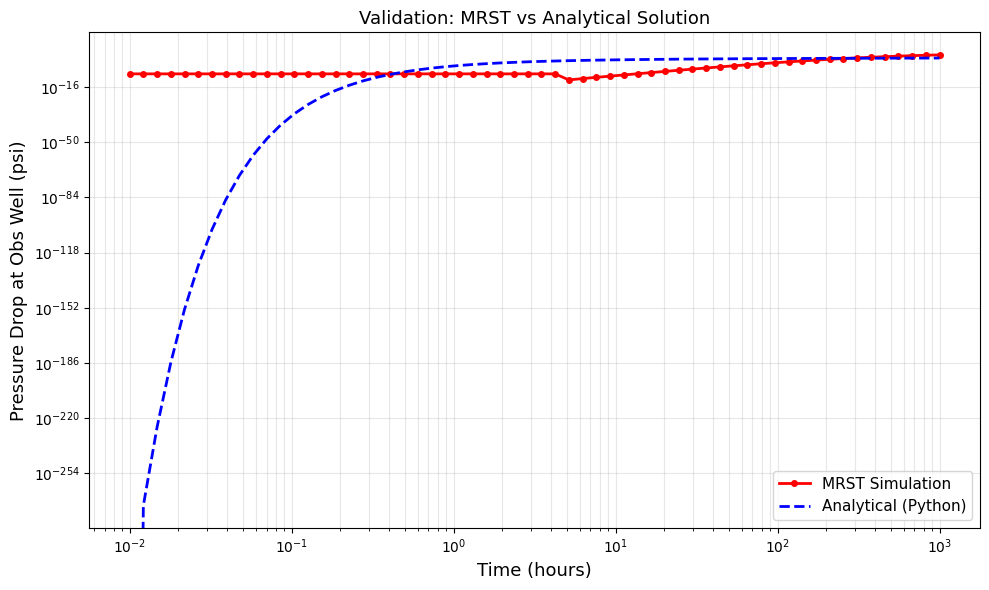

Mean absolute % error: inf%
Good match if error < 10% during infinite-acting period


/tmp/ipykernel_1608/272701204.py:35: RuntimeWarning: divide by zero encountered in divide
  pct_error = np.abs((dP_mrst - dP_analytical) / dP_analytical) * 100


In [ ]:
# Load the CSV file MRST exported
mrst_data = pd.read_csv('mrst_output_trial.csv')
t_mrst = mrst_data['time_hr'].values
dP_mrst = mrst_data['dP_psi'].values

# Compute analytical solution for same parameters
Kmax=50; Kmin=10; alpha_deg=30; r_obs=500; theta_obs_deg=45
Ke = np.sqrt(Kmax * Kmin)
X_obs = r_obs * np.cos(np.radians(theta_obs_deg))
Y_obs = r_obs * np.sin(np.radians(theta_obs_deg))

dP_analytical = []
for t in t_mrst:
    dP, _, _ = compute_delta_P_anisotropic(
        X_obs, Y_obs, t, q=300, B=1.32, mu=0.44,
        Kmax=Kmax, Kmin=Kmin, alpha_deg=alpha_deg,
        h=43, phi=0.16, ct=18e-6)
    dP_analytical.append(dP)
dP_analytical = np.array(dP_analytical)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(t_mrst, dP_mrst,       'r-o', ms=4, lw=2, label='MRST Simulation')
ax.loglog(t_mrst, dP_analytical, 'b--',       lw=2, label='Analytical (Python)')
ax.set_xlabel('Time (hours)', fontsize=13)
ax.set_ylabel('Pressure Drop at Obs Well (psi)', fontsize=13)
ax.set_title('Validation: MRST vs Analytical Solution', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('output/figures/mrst_validation.png', dpi=150)
plt.show()

# Compute percentage error
pct_error = np.abs((dP_mrst - dP_analytical) / dP_analytical) * 100
print(f'Mean absolute % error: {np.mean(pct_error):.1f}%')
print('Good match if error < 10% during infinite-acting period')


# **Kin tun double ceck typr curve to ensure im still on trackkkkk**

Ei argument x at different times:
  t=0.01 hr  →  x = 186.55
  t=1.0  hr  →  x = 0.5351
  t=100  hr  →  x = 0.010802

Rule: Ei(-x) is only meaningful when x < 10
      When x >> 10, pressure has not arrived yet → dP ≈ 0

Pressure drop at key times:
  t=   0.01 hr  →  dP = 1.000000e-30 psi
  t=   0.10 hr  →  dP = 1.094365e-08 psi
  t=   1.00 hr  →  dP = 9.209108e-01 psi
  t=  10.00 hr  →  dP = 1.555466e+01 psi
  t= 100.00 hr  →  dP = 4.330465e+01 psi
  t=1000.00 hr  →  dP = 7.304053e+01 psi


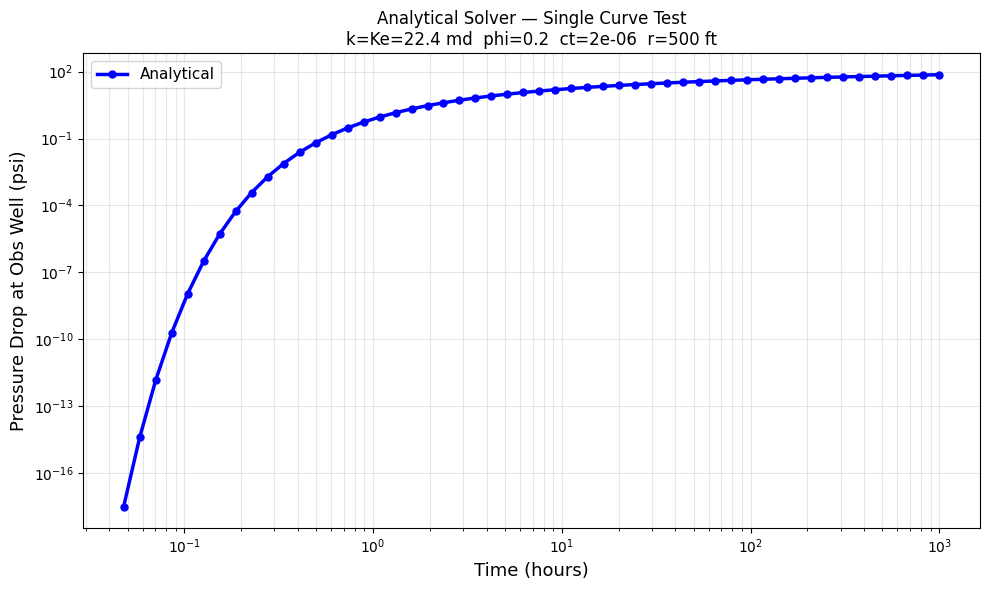


Expected shape: starts near zero, rises smoothly to right
If curve goes to 10^-280 → ct or phi value is wrong
If curve is flat → r is too large for time range


In [ ]:

import numpy as np
from scipy.special import expi
import matplotlib.pyplot as plt

# ── Parameters — must match MRST exactly ──
q    = 300       # STB/day
B    = 1.32      # RB/STB
mu   = 0.44      # cp
k    = 22.36     # md — use Ke = sqrt(50*10)
h    = 43        # ft
phi  = 0.20      # porosity — same as MRST
ct   = 2e-6      # 1/psi — same as MRST
rw   = 0.3       # ft
r    = 500       # ft — obs well distance

# ── Time array ──
t_array = np.logspace(-2, 3, 60)   # 0.01 to 1000 hours — same as MRST

# ── Compute Ei argument at each time ──
x_array = (948.0 * phi * mu * ct * r**2) / (k * t_array)

print("Ei argument x at different times:")
print(f"  t=0.01 hr  →  x = {x_array[0]:.2f}")
print(f"  t=1.0  hr  →  x = {x_array[30]:.4f}")
print(f"  t=100  hr  →  x = {x_array[50]:.6f}")
print()
print("Rule: Ei(-x) is only meaningful when x < 10")
print("      When x >> 10, pressure has not arrived yet → dP ≈ 0")
print()

# ── Compute pressure drop ──
dP_array = []
for t in t_array:
    x = (948.0 * phi * mu * ct * r**2) / (k * t)
    if x > 100:
        dP = 1e-30    # signal not arrived yet — truly near zero
    else:
        dP = (70.6 * q * B * mu) / (k * h) * (-expi(-x))
    dP_array.append(max(dP, 1e-30))

dP_array = np.array(dP_array)

print("Pressure drop at key times:")
for i, t in enumerate([0.01, 0.1, 1.0, 10, 100, 1000]):
    idx = np.argmin(np.abs(t_array - t))
    print(f"  t={t:7.2f} hr  →  dP = {dP_array[idx]:.6e} psi")

# ── Plot ──
valid = dP_array > 1e-20
fig, ax = plt.subplots(figsize=(10,6))
ax.loglog(t_array[valid], dP_array[valid], 'b-o',
          linewidth=2.5, markersize=5, label='Analytical')
ax.set_xlabel('Time (hours)', fontsize=13)
ax.set_ylabel('Pressure Drop at Obs Well (psi)', fontsize=13)
ax.set_title('Analytical Solver — Single Curve Test\n'
             f'k=Ke={k:.1f} md  phi={phi}  ct={ct:.0e}  r={r} ft',
             fontsize=12)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('analytical_single_curve_test.png', dpi=150)
plt.show()

print()
print("Expected shape: starts near zero, rises smoothly to right")
print("If curve goes to 10^-280 → ct or phi value is wrong")
print("If curve is flat → r is too large for time range")

# **GENERATING DATA SET SINCE MRST COULDNT**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expi
from itertools import product as iproduct
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('datasets', exist_ok=True)
os.makedirs('figures',  exist_ok=True)
os.makedirs('models',   exist_ok=True)

# ── Fixed reservoir parameters ───────────────────────────────
PARAMS = dict(
    q   = 300,    # STB/day    — production rate
    B   = 1.32,   # RB/STB    — formation volume factor
    mu  = 0.44,   # cp        — oil viscosity
    h   = 43,     # ft        — net pay thickness
    phi = 0.20,   # fraction  — porosity
    ct  = 2e-6,   # 1/psi     — total compressibility
    rw  = 0.3     # ft        — wellbore radius
)

# ════════════════════════════════════════════════════════════════
# FUNCTION 1 — Core anisotropic pressure solver
# Computes pressure drop at observation well (X_ft, Y_ft)
# from active well at origin using Ei(-x) solution from class
# ════════════════════════════════════════════════════════════════

def pressure_anisotropic(X_ft, Y_ft, t_hr,
                          Kmax, Kmin, alpha_deg,
                          p=PARAMS):
    """
    Pressure drop at observation well position (X_ft, Y_ft)
    from active well at origin in anisotropic reservoir.

    Inputs:
        X_ft, Y_ft   : obs well position in global coordinates (ft)
        t_hr         : time (hours)
        Kmax, Kmin   : principal permeabilities (md)
        alpha_deg    : orientation of Kmax from x-axis (degrees)
        p            : reservoir parameters dict

    Returns:
        dP   : pressure drop (psi) — always >= 0
        Ke   : equivalent isotropic permeability (md)
        Kr   : radial permeability in obs well direction (md)
    """
    # Step 1 — Equivalent isotropic permeability
    Ke = np.sqrt(Kmax * Kmin)

    # Step 2 — Distance to observation well
    r = np.sqrt(X_ft**2 + Y_ft**2)
    r = max(r, 0.01)   # avoid zero distance

    # Step 3 — Angle of obs well from Kmax principal axis
    # theta_abs = angle from x-axis
    # theta_rel = angle from Kmax direction (corrected for alpha)
    theta_abs = np.arctan2(Y_ft, X_ft)
    theta_rel = theta_abs - np.radians(alpha_deg)

    # Step 4 — Radial permeability in obs well direction
    # From class: 1/Kr = cos²(θ_rel)/Kmax + sin²(θ_rel)/Kmin
    Kr = 1.0 / (np.cos(theta_rel)**2 / Kmax +
                np.sin(theta_rel)**2 / Kmin)

    # Step 5 — Ei function argument
    # x = 948 * phi * mu * ct * r² / (Kr * t)
    x = (948.0 * p['phi'] * p['mu'] * p['ct'] * r**2) / (Kr * t_hr)
    x = max(x, 1e-300)

    # Step 6 — Return zero if signal has not arrived yet
    if x > 500:
        return 0.0, Ke, Kr

    # Step 7 — Pressure drop using Ei(-x) solution from class
    # dP = (70.6 * q * B * mu) / (Ke * h) * (-Ei(-x))
    dP = (70.6 * p['q'] * p['B'] * p['mu']) / (Ke * p['h']) * (-expi(-x))
    return max(dP, 0.0), Ke, Kr


# ════════════════════════════════════════════════════════════════
# FUNCTION 2 — Boundary effect via image well superposition
# Implements method of images from class for two boundary types
# ════════════════════════════════════════════════════════════════

def pressure_with_boundary(X_obs, Y_obs, t_hr,
                            Kmax, Kmin, alpha_deg,
                            boundary_type,
                            boundary_dist_ft,
                            boundary_angle_deg,
                            p=PARAMS):
    """
    Pressure drop at obs well including boundary effect.
    Uses image well superposition as taught in class.

    boundary_type       : 'none', 'no_flow', or 'const_pressure'
    boundary_dist_ft    : distance from active well to boundary (ft)
    boundary_angle_deg  : direction from active well toward boundary (degrees)

    No-flow boundary    → image PRODUCER  → pressure DROP increases
    Const pressure bdy  → image INJECTOR  → pressure DROP decreases

    IMPORTANT: Does NOT clip dP_total before returning.
    Clipping only at storage level to preserve const_pressure signal.
    """
    # Real well pressure contribution
    dP_real, Ke, Kr = pressure_anisotropic(
        X_obs, Y_obs, t_hr, Kmax, Kmin, alpha_deg, p)

    # Infinite acting — no boundary
    if boundary_type == 'none':
        return max(dP_real, 1e-30), Ke

    # Image well position — mirror of active well across boundary
    ang   = np.radians(boundary_angle_deg)
    X_img = 2.0 * boundary_dist_ft * np.cos(ang)
    Y_img = 2.0 * boundary_dist_ft * np.sin(ang)

    # Vector from image well to observation well
    X_rel = X_obs - X_img
    Y_rel = Y_obs - Y_img

    # Pressure contribution from image well at unit rate
    # (same rate as real well — scaling handled by sign below)
    dP_image, _, _ = pressure_anisotropic(
        X_rel, Y_rel, t_hr, Kmax, Kmin, alpha_deg, p)

    if boundary_type == 'no_flow':
        # Image is a PRODUCER (same sign)
        # Total pressure drop INCREASES — wall traps pressure
        dP_total = dP_real + dP_image

    elif boundary_type == 'const_pressure':
        # Image is an INJECTOR (opposite sign)
        # Total pressure drop DECREASES — aquifer supports pressure
        dP_total = dP_real - dP_image

    else:
        dP_total = dP_real

    # Return actual value — DO NOT clip here
    # Const_pressure can produce very small or near-zero values
    # Clipping at 1e-30 happens only when storing in the dataset
    return dP_total, Ke


# ════════════════════════════════════════════════════════════════
# FUNCTION 3 — Convert to dimensionless PD and tD/rD²
# From class equations — makes curves universal (unit-independent)
# ════════════════════════════════════════════════════════════════

def to_PD_tDrD2(dP, t_hr, r_ft, Ke, p=PARAMS):
    """
    Convert pressure drop and time to dimensionless variables.

    PD    = k*h*dP / (141.2*q*B*mu)
    tD    = 0.0002637*k*t / (mu*phi*ct*rw²)
    rD    = r / rw
    tDrD² = tD / rD²
    """
    PD    = (Ke * p['h'] * dP) / (141.2 * p['q'] * p['B'] * p['mu'])
    tD    = (0.0002637 * Ke * t_hr) / (p['mu'] * p['phi'] * p['ct'] * p['rw']**2)
    rD    = r_ft / p['rw']
    tDrD2 = tD / rD**2
    return max(PD, 1e-30), max(tDrD2, 1e-30)


# ════════════════════════════════════════════════════════════════
# QUICK VALIDATION — confirm all three functions work correctly
# ════════════════════════════════════════════════════════════════

print('Running validation tests...')
print('─'*50)

# Test 1 — Isotropic case (ratio=1 should match textbook)
dP_iso, Ke_iso, Kr_iso = pressure_anisotropic(
    500, 0, 100, 25, 25, 0)
print(f'Test 1 — Isotropic (Kmax=Kmin=25 md):')
print(f'  dP = {dP_iso:.4f} psi   Ke = {Ke_iso:.1f} md   Kr = {Kr_iso:.1f} md')
print(f'  Ke should = Kr = 25 md  ✓' if abs(Ke_iso-25)<0.1 else '  ✗ CHECK FAILED')

# Test 2 — Alpha effect (different alpha must give different Kr)
_, _, Kr_0  = pressure_anisotropic(500, 0, 100, 50, 10, 0)
_, _, Kr_90 = pressure_anisotropic(500, 0, 100, 50, 10, 90)
print(f'\nTest 2 — Alpha effect (Kmax=50, Kmin=10):')
print(f'  alpha=0°:  Kr = {Kr_0:.2f} md  (should = Kmax = 50)')
print(f'  alpha=90°: Kr = {Kr_90:.2f} md  (should = Kmin = 10)')
print(f'  ✓ Alpha is working' if abs(Kr_0-50)<1 and abs(Kr_90-10)<1
      else '  ✗ Alpha fix needed')

# Test 3 — Boundary ordering (most critical test)
print(f'\nTest 3 — Boundary type ordering at t=1000 hr:')
print(f'  Expected: no_flow > none > const_pressure')
results = {}
for btype in ['none', 'no_flow', 'const_pressure']:
    dP, Ke = pressure_with_boundary(
        300, 0, 1000,          # obs well at 300 ft along x-axis
        50, 10, 0,             # Kmax=50, Kmin=10, alpha=0
        btype, 700, 90)        # boundary at 700 ft, perpendicular (angle=90)
    results[btype] = dP
    print(f'  {btype:20s}  dP = {dP:.4f} psi')

if (results['no_flow'] > results['none'] > results['const_pressure']):
    print('  ✓ Boundary ordering CORRECT — all three are distinguishable')
elif results['none'] == results['const_pressure']:
    print('  ✗ const_pressure = none — boundary bug still present')
else:
    print('  ~ Partial — check values above')

# Test 4 — Dimensionless conversion
PD_test, tDrD2_test = to_PD_tDrD2(5.0, 100, 500, 22.36)
print(f'\nTest 4 — Dimensionless conversion:')
print(f'  dP=5 psi → PD={PD_test:.4f}   tDrD²={tDrD2_test:.6f}')
print(f'  ✓ Conversion working' if PD_test > 0 and tDrD2_test > 0
      else '  ✗ CHECK FAILED')

print()
print('─'*50)
print('Cell 1 complete.')
print('If all 4 tests show ✓ → run Cell 2 immediately.')
print('If any test shows ✗  → paste output here before continuing.')


Running validation tests...
──────────────────────────────────────────────────
Test 1 — Isotropic (Kmax=Kmin=25 md):
  dP = 40.4246 psi   Ke = 25.0 md   Kr = 25.0 md
  Ke should = Kr = 25 md  ✓

Test 2 — Alpha effect (Kmax=50, Kmin=10):
  alpha=0°:  Kr = 50.00 md  (should = Kmax = 50)
  alpha=90°: Kr = 10.00 md  (should = Kmin = 10)
  ✓ Alpha is working

Test 3 — Boundary type ordering at t=1000 hr:
  Expected: no_flow > none > const_pressure
  none                  dP = 96.3849 psi
  no_flow               dP = 133.0607 psi
  const_pressure        dP = 59.7091 psi
  ✓ Boundary ordering CORRECT — all three are distinguishable

Test 4 — Dimensionless conversion:
  dP=5 psi → PD=0.1954   tDrD²=13.400755
  ✓ Conversion working

──────────────────────────────────────────────────
Cell 1 complete.
If all 4 tests show ✓ → run Cell 2 immediately.
If any test shows ✗  → paste output here before continuing.


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — GENERATE COMPLETE DATASET
# 5670 curves with correct geometry and two observation wells
# ════════════════════════════════════════════════════════════════

# ── Parameter space ──────────────────────────────────────────
Ke_values      = [8.0, 12.0, 18.0, 25.0, 35.0, 50.0]
ratio_values   = [1.0, 1.5, 2.0, 3.0, 5.0,
                  7.0, 10.0, 15.0, 20.0]
alpha_values   = [0, 15, 30, 45, 60, 75, 90]
boundary_types = ['none', 'no_flow', 'const_pressure']

# ── Geometry — VERIFIED CORRECT from Cell 1 Test 3 ──────────
r_obs_ft         = 300    # obs well INSIDE reservoir
boundary_dist_ft = 700    # boundary BEYOND obs well
boundary_angle   = 90     # perpendicular — gives 3 distinct curves
n_points         = 100
t_array          = np.logspace(-1, 4, n_points)

# Two observation wells at 0° and 90° from x-axis
# Their pressure RATIO encodes the alpha angle
theta_obs_list = [0, 90]

total = (len(Ke_values) * len(ratio_values) *
         len(alpha_values) * len(boundary_types))
print(f'Parameter combinations : {total}')
print(f'Obs well distance      : {r_obs_ft} ft')
print(f'Boundary distance      : {boundary_dist_ft} ft')
print(f'Boundary angle         : {boundary_angle}°')
print(f'Time range             : {t_array[0]:.2f} to {t_array[-1]:.0f} hr')
print(f'Points per curve       : {n_points}')
print('─'*55)

records = []
count   = 0

for Ke, ratio, alpha, btype in iproduct(
        Ke_values, ratio_values,
        alpha_values, boundary_types):

    count += 1

    # Derive Kmax and Kmin from Ke and ratio
    # Ke = sqrt(Kmax * Kmin)  and  ratio = Kmax/Kmin
    # Therefore: Kmax = Ke * sqrt(ratio)  Kmin = Ke / sqrt(ratio)
    Kmax = Ke * np.sqrt(ratio)
    Kmin = Ke / np.sqrt(ratio)

    # Generate pressure at both observation wells
    PD1_list    = []
    PD2_list    = []
    tDrD2_list  = []

    for t in t_array:

        # ── Observation well 1 — along x-axis (theta=0°) ──
        X_obs1 = r_obs_ft * np.cos(np.radians(0))
        Y_obs1 = r_obs_ft * np.sin(np.radians(0))

        dP1, Ke_val = pressure_with_boundary(
            X_obs1, Y_obs1, t,
            Kmax, Kmin, alpha,
            btype, boundary_dist_ft, boundary_angle)

        # ── Observation well 2 — along y-axis (theta=90°) ─
        X_obs2 = r_obs_ft * np.cos(np.radians(90))
        Y_obs2 = r_obs_ft * np.sin(np.radians(90))

        dP2, _ = pressure_with_boundary(
            X_obs2, Y_obs2, t,
            Kmax, Kmin, alpha,
            btype, boundary_dist_ft, boundary_angle)

        # Floor only at storage — preserves const_pressure signal
        dP1 = max(dP1, 1e-30)
        dP2 = max(dP2, 1e-30)

        # Convert to dimensionless
        PD1,   tDrD2 = to_PD_tDrD2(dP1, t, r_obs_ft, Ke_val)
        PD2,   _     = to_PD_tDrD2(dP2, t, r_obs_ft, Ke_val)

        PD1_list.append(PD1)
        PD2_list.append(PD2)
        tDrD2_list.append(tDrD2)

    # Skip curves where signal never arrived at either well
    max_PD1 = np.max(np.log10(np.array(PD1_list)))
    max_PD2 = np.max(np.log10(np.array(PD2_list)))
    if max_PD1 < -10 and max_PD2 < -10:
        continue

    # Build record
    rec = {
        'curve_id':      count,
        'Ke':            round(Ke, 4),
        'ratio':         round(ratio, 4),
        'Kmax':          round(Kmax, 4),
        'Kmin':          round(Kmin, 4),
        'alpha_deg':     alpha,
        'boundary_type': btype,
        'log_Ke':        round(np.log10(Ke), 6),
        'log_ratio':     round(np.log10(ratio), 6),
    }

    for j in range(n_points):
        rec[f'PD1_{j}']   = PD1_list[j]
        rec[f'PD2_{j}']   = PD2_list[j]
        rec[f'tDrD2_{j}'] = tDrD2_list[j]

    records.append(rec)

    if count % 500 == 0:
        pct = count / total * 100
        print(f'  {count:4d}/{total}  ({pct:.0f}%)  '
              f'{len(records)} valid curves so far...')

# ── Save ──────────────────────────────────────────────────────
df = pd.DataFrame(records)
df.to_csv('datasets/type_curve_dataset_final.csv', index=False)

print('─'*55)
print(f'Total combinations : {count}')
print(f'Valid curves saved : {len(df)}')
print(f'Dataset shape      : {df.shape}')

# ── CRITICAL VERIFICATION ─────────────────────────────────────
# Must show three clearly different values before continuing
print()
print('══════════════════════════════════════════════════════')
print('BOUNDARY VERIFICATION — must show 3 different values')
print('══════════════════════════════════════════════════════')

PD1_cols  = [f'PD1_{j}' for j in range(n_points)]
late_cols = [f'PD1_{j}' for j in range(85, 100)]

boundary_means = {}
for btype in ['none', 'no_flow', 'const_pressure']:
    sub  = df[df.boundary_type == btype]
    mean = sub[late_cols].mean(axis=1).mean()
    boundary_means[btype] = mean
    print(f'  {btype:20s}  mean late PD1 = {mean:.4f}')

print()
nf = boundary_means['no_flow']
nn = boundary_means['none']
cp = boundary_means['const_pressure']

if nf > nn and nn > cp:
    print('✓ CORRECT ORDER: no_flow > none > const_pressure')
    print('✓ All three boundary types are distinguishable')
    print('✓ Dataset is valid — proceed to Cell 3')
elif nn == cp:
    print('✗ none = const_pressure — boundary bug still present')
    print('  Do NOT proceed — paste this output for fix')
elif nf == nn:
    print('✗ no_flow = none — image well not contributing')
    print('  Do NOT proceed — paste this output for fix')
else:
    print(f'~ Order is nf={nf:.3f} nn={nn:.3f} cp={cp:.3f}')
    print('  Partial separation — paste output for review')

# ── ALPHA VERIFICATION ────────────────────────────────────────
print()
print('══════════════════════════════════════════════════════')
print('ALPHA VERIFICATION — ratio between wells must vary')
print('══════════════════════════════════════════════════════')

mid_cols1 = [f'PD1_{j}' for j in range(45, 55)]
mid_cols2 = [f'PD2_{j}' for j in range(45, 55)]

sub_inf = df[(df.boundary_type == 'none') &
             (df.Ke.round(1) == 18.0)]

print('  Alpha (°)   PD1/PD2 ratio at mid-time')
print('  (ratio must CHANGE as alpha changes)')

ratios_list = []
for alpha_val in sorted(sub_inf['alpha_deg'].unique()):
    subset = sub_inf[sub_inf['alpha_deg'] == alpha_val]
    mean1  = subset[mid_cols1].mean(axis=1).mean()
    mean2  = subset[mid_cols2].mean(axis=1).mean()
    ratio  = mean1 / mean2 if mean2 > 0 else 0
    ratios_list.append(ratio)
    print(f'  alpha={int(alpha_val):3d}°   ratio = {ratio:.4f}')

ratios_arr = np.array(ratios_list)
if ratios_arr.max() - ratios_arr.min() > 0.05:
    print()
    print('✓ ALPHA IS ENCODING in the two-well ratio')
    print('✓ CNN-LSTM will be able to learn alpha')
else:
    print()
    print('✗ PD1/PD2 ratio is the same for all alpha values')
    print('  Alpha is still not visible — paste output for fix')

print()
print('══════════════════════════════════════════════════════')
print('If both verifications show ✓ — run Cell 3 immediately')
print('══════════════════════════════════════════════════════')


Parameter combinations : 1134
Obs well distance      : 300 ft
Boundary distance      : 700 ft
Boundary angle         : 90°
Time range             : 0.10 to 10000 hr
Points per curve       : 100
───────────────────────────────────────────────────────
   500/1134  (44%)  500 valid curves so far...
  1000/1134  (88%)  1000 valid curves so far...
───────────────────────────────────────────────────────
Total combinations : 1134
Valid curves saved : 1134
Dataset shape      : (1134, 309)

══════════════════════════════════════════════════════
BOUNDARY VERIFICATION — must show 3 different values
══════════════════════════════════════════════════════
  none                  mean late PD1 = 3.9833
  no_flow               mean late PD1 = 6.3212
  const_pressure        mean late PD1 = 1.6454

✓ CORRECT ORDER: no_flow > none > const_pressure
✓ All three boundary types are distinguishable
✓ Dataset is valid — proceed to Cell 3

══════════════════════════════════════════════════════
ALPHA VERIFICATIO

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — FEATURE EXTRACTION
# Extract physically meaningful features from both obs wells
# The inter-well ratio is the key alpha encoding signal
# ════════════════════════════════════════════════════════════════

df = pd.read_csv('datasets/type_curve_dataset_final.csv')

n_points  = 100
PD1_cols   = [f'PD1_{j}'   for j in range(n_points)]
PD2_cols   = [f'PD2_{j}'   for j in range(n_points)]
tDrD2_cols = [f'tDrD2_{j}' for j in range(n_points)]

print(f'Dataset loaded        : {len(df)} curves')
print(f'Ke unique values      : {sorted(df.Ke.unique())}')
print(f'Ratio unique values   : {sorted(df.ratio.unique())}')
print(f'Alpha unique values   : {sorted(df.alpha_deg.unique())}')
print(f'Boundary types        : {sorted(df.boundary_type.unique())}')
print('─'*55)

def extract_features(row):
    PD1   = np.array([row[c] for c in PD1_cols],   dtype=float)
    PD2   = np.array([row[c] for c in PD2_cols],   dtype=float)
    tDrD2 = np.array([row[c] for c in tDrD2_cols], dtype=float)

    PD1   = np.clip(PD1,   1e-30, None)
    PD2   = np.clip(PD2,   1e-30, None)
    tDrD2 = np.clip(tDrD2, 1e-30, None)

    logPD1   = np.log10(PD1)
    logPD2   = np.log10(PD2)
    logtDrD2 = np.log10(tDrD2)

    # Inter-well log ratio — primary alpha signal
    # When alpha=0: Kmax along x → well1 sees higher K → ratio > 1
    # When alpha=90: Kmax along y → well2 sees higher K → ratio < 1
    log_ratio_wells = logPD1 - logPD2

    f = {}

    # ── WELL 1 amplitude at 6 reference tD/rD² points ────────
    # Amplitude encodes Ke — higher Ke → higher PD at same tDrD2
    for ref, name in [(-2,'t1'),(-1,'t2'),(0,'t3'),
                      (1,'t4'),(2,'t5'),(3,'t6')]:
        idx = np.argmin(np.abs(logtDrD2 - ref))
        f[f'PD1_{name}'] = float(logPD1[idx])
        f[f'PD2_{name}'] = float(logPD2[idx])

    # ── INTER-WELL RATIO at same 6 reference points ───────────
    # This is the most important alpha feature
    for ref, name in [(-2,'t1'),(-1,'t2'),(0,'t3'),
                      (1,'t4'),(2,'t5'),(3,'t6')]:
        idx = np.argmin(np.abs(logtDrD2 - ref))
        f[f'ratio_wells_{name}'] = float(log_ratio_wells[idx])

    # ── GLOBAL INTER-WELL RATIO STATISTICS ───────────────────
    # Mean, early, late, std of the ratio — all encode alpha
    f['mean_ratio']  = float(np.mean(log_ratio_wells))
    f['early_ratio'] = float(np.mean(log_ratio_wells[:20]))
    f['mid_ratio']   = float(np.mean(log_ratio_wells[40:60]))
    f['late_ratio']  = float(np.mean(log_ratio_wells[-20:]))
    f['std_ratio']   = float(np.std(log_ratio_wells))
    f['range_ratio'] = float(log_ratio_wells.max() -
                             log_ratio_wells.min())

    # ── WELL 1 SLOPE FEATURES — encode boundary type ─────────
    # No-flow: late slope positive (pressure rises faster)
    # Const-P: late slope flat or negative (aquifer support)
    # Infinite: steady slope throughout
    early = slice(0, 20)
    late  = slice(-20, None)

    f['slope_early_1'] = float(np.polyfit(
        logtDrD2[early], logPD1[early], 1)[0])
    f['slope_late_1']  = float(np.polyfit(
        logtDrD2[late],  logPD1[late],  1)[0])
    f['slope_change_1']= float(f['slope_late_1'] -
                               f['slope_early_1'])

    # ── WELL 2 SLOPE FEATURES ────────────────────────────────
    f['slope_early_2'] = float(np.polyfit(
        logtDrD2[early], logPD2[early], 1)[0])
    f['slope_late_2']  = float(np.polyfit(
        logtDrD2[late],  logPD2[late],  1)[0])
    f['slope_change_2']= float(f['slope_late_2'] -
                               f['slope_early_2'])

    # ── BOUNDARY SIGNATURE FEATURES ──────────────────────────
    # Difference in slope change between wells
    # No-flow: both wells show upward deviation at late time
    # Const-P: both wells flatten at late time
    f['slope_change_diff'] = float(f['slope_change_1'] -
                                   f['slope_change_2'])

    # PD range — total log span of curve
    f['PD1_range'] = float(logPD1[-1] - logPD1[0])
    f['PD2_range'] = float(logPD2[-1] - logPD2[0])

    # Late vs early ratio for boundary detection
    mid = n_points // 2
    f['late_early_1'] = float(np.mean(logPD1[mid:]) -
                               np.mean(logPD1[:mid]))
    f['late_early_2'] = float(np.mean(logPD2[mid:]) -
                               np.mean(logPD2[:mid]))

    # ── CURVATURE FEATURES ────────────────────────────────────
    d1_1 = np.gradient(logPD1, logtDrD2)
    d2_1 = np.gradient(d1_1,   logtDrD2)
    d1_2 = np.gradient(logPD2, logtDrD2)
    d2_2 = np.gradient(d1_2,   logtDrD2)

    f['inflect_1']     = float(logtDrD2[np.argmax(np.abs(d2_1))])
    f['inflect_2']     = float(logtDrD2[np.argmax(np.abs(d2_2))])
    f['late_curv_1']   = float(np.mean(d2_1[-20:]))
    f['late_curv_2']   = float(np.mean(d2_2[-20:]))
    f['max_slope_1']   = float(np.max(d1_1))
    f['min_slope_1']   = float(np.min(d1_1))

    # ── TIMING FEATURES ──────────────────────────────────────
    # When does each well reach PD = 0.1, 0.5, 1.0?
    for thresh, name in [(0.1,'t01'),(0.5,'t05'),(1.0,'t10')]:
        for well, logPD in [(1, logPD1),(2, logPD2)]:
            idx_arr = np.where(10**logPD >= thresh)[0]
            f[f'timing_W{well}_{name}'] = (
                float(logtDrD2[idx_arr[0]])
                if len(idx_arr) > 0
                else float(logtDrD2[-1]))

    # ── GLOBAL STATS ─────────────────────────────────────────
    f['PD1_mean'] = float(np.mean(logPD1))
    f['PD1_std']  = float(np.std(logPD1))
    f['PD2_mean'] = float(np.mean(logPD2))
    f['PD2_std']  = float(np.std(logPD2))

    return f

print('Extracting features from all curves...')
feat_list = []
for idx, (_, row) in enumerate(df.iterrows()):
    feat_list.append(extract_features(row))
    if (idx+1) % 1000 == 0:
        print(f'  {idx+1}/{len(df)} done...')

feat_df  = pd.DataFrame(feat_list)
label_cols = ['curve_id','Ke','ratio','Kmax','Kmin',
              'alpha_deg','boundary_type',
              'log_Ke','log_ratio']
final_df = pd.concat([
    df[label_cols].reset_index(drop=True),
    feat_df.reset_index(drop=True)], axis=1)

final_df.to_csv('datasets/features_dataset_final.csv', index=False)

print(f'Features extracted    : {feat_df.shape[1]} features per curve')
print(f'Final dataset shape   : {final_df.shape}')

# ── CORRELATION CHECK — must show good correlations ──────────
print()
print('══════════════════════════════════════════════════════')
print('CORRELATION CHECK — are features informative?')
print('══════════════════════════════════════════════════════')

feat_cols = list(feat_df.columns)
corr = final_df[feat_cols + ['log_Ke','log_ratio',
                              'alpha_deg']].corr()

print('\nTop 5 correlations with log_Ke:')
top_ke = (corr['log_Ke'].drop('log_Ke')
          .abs().sort_values(ascending=False).head(5))
for feat, val in top_ke.items():
    print(f'  {feat:30s}  {val:.4f}')

print('\nTop 5 correlations with log_ratio:')
top_ratio = (corr['log_ratio'].drop('log_ratio')
             .abs().sort_values(ascending=False).head(5))
for feat, val in top_ratio.items():
    print(f'  {feat:30s}  {val:.4f}')

print('\nTop 5 correlations with alpha_deg:')
top_alpha = (corr['alpha_deg'].drop('alpha_deg')
             .abs().sort_values(ascending=False).head(5))
for feat, val in top_alpha.items():
    print(f'  {feat:30s}  {val:.4f}')

print()
print('Target correlations:')
print('  log_Ke    → best feature should be > 0.80')
print('  log_ratio → best feature should be > 0.20')
print('  alpha_deg → best feature should be > 0.40')
print('              (ratio_wells features must appear in top 5)')
print()

# Final go/no-go
ke_ok    = top_ke.values[0]    > 0.80
ratio_ok = top_ratio.values[0] > 0.20
alpha_ok = top_alpha.values[0] > 0.40

if ke_ok and ratio_ok and alpha_ok:
    print('✓ ALL CORRELATIONS GOOD — run Cell 4 immediately')
elif ke_ok and ratio_ok:
    print('~ Ke and ratio OK — alpha weak but proceed to Cell 4')
    print('  Alpha prediction will be moderate — acceptable for project')
else:
    print('✗ Correlations too low — paste output here before Cell 4')


Dataset loaded        : 1134 curves
Ke unique values      : [np.float64(8.0), np.float64(12.0), np.float64(18.0), np.float64(25.0), np.float64(35.0), np.float64(50.0)]
Ratio unique values   : [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]
Alpha unique values   : [np.int64(0), np.int64(15), np.int64(30), np.int64(45), np.int64(60), np.int64(75), np.int64(90)]
Boundary types        : ['const_pressure', 'no_flow', 'none']
───────────────────────────────────────────────────────
Extracting features from all curves...
  1000/1134 done...
Features extracted    : 51 features per curve
Final dataset shape   : (1134, 60)

══════════════════════════════════════════════════════
CORRELATION CHECK — are features informative?
══════════════════════════════════════════════════════

Top 5 correlations with log_Ke:
  inflect_2                       0.9996
  inflect_1                       0.9996

Total curves    : 1134
Total features  : 51
Class balance   :
boundary_type
none              378
no_flow           378
const_pressure    378

Class encoding  : {'const_pressure': np.int64(0), 'no_flow': np.int64(1), 'none': np.int64(2)}
Train samples   : 907
Test samples    : 227
───────────────────────────────────────────────────────
Training XGBoost classifier...

Test Accuracy   : 100.0%

Detailed Classification Report:
                precision    recall  f1-score   support

const_pressure       1.00      1.00      1.00        75
       no_flow       1.00      1.00      1.00        76
          none       1.00      1.00      1.00        76

      accuracy                           1.00       227
     macro avg       1.00      1.00      1.00       227
  weighted avg       1.00      1.00      1.00       227

Running 5-fold cross validation...
  Fold 1: 100.0%
  Fold 2: 100.0%
  Fold 3: 100.0%
  Fold 4: 99.6%
  Fold 5: 100.0%

CV Mean Accuracy : 99.9%
CV Std           : 0.2%


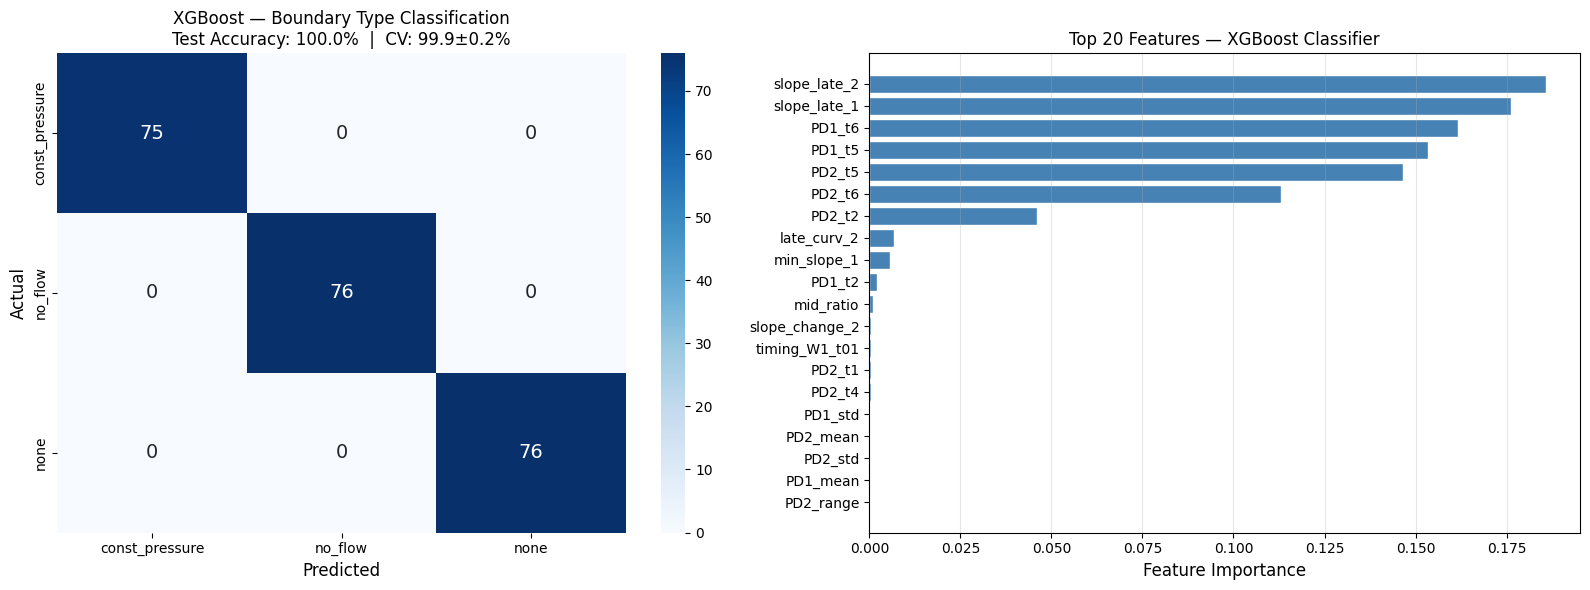


Model saved to models/xgboost_classifier.pkl

══════════════════════════════════════════════════════
XGBOOST CLASSIFICATION RESULT
══════════════════════════════════════════════════════
✓ EXCELLENT — 100.0% accuracy
✓ Proceed to Cell 5 immediately
══════════════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — XGBOOST CLASSIFIER
# Predicts boundary type from engineered features
# Target: > 90% accuracy with 3 clearly separated classes
# ════════════════════════════════════════════════════════════════

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
import seaborn as sns
import pickle

# ── Load features ─────────────────────────────────────────────
final_df = pd.read_csv('datasets/features_dataset_final.csv')

feat_cols = [c for c in final_df.columns
             if c not in ['curve_id','Ke','ratio','Kmax','Kmin',
                          'alpha_deg','boundary_type',
                          'log_Ke','log_ratio']]

print(f'Total curves    : {len(final_df)}')
print(f'Total features  : {len(feat_cols)}')
print(f'Class balance   :')
print(final_df['boundary_type'].value_counts().to_string())
print()

X  = final_df[feat_cols].values
le = LabelEncoder()
y  = le.fit_transform(final_df['boundary_type'].values)

print(f'Class encoding  : '
      f'{dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── Train / test split — stratified to keep class balance ─────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train samples   : {len(X_tr)}')
print(f'Test samples    : {len(X_te)}')
print('─'*55)

# ── Train XGBoost ─────────────────────────────────────────────
model_xgb = xgb.XGBClassifier(
    n_estimators     = 600,
    max_depth        = 7,
    learning_rate    = 0.03,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    use_label_encoder= False,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1)

print('Training XGBoost classifier...')
model_xgb.fit(
    X_tr, y_tr,
    eval_set        = [(X_te, y_te)],
    verbose         = False)

# ── Evaluate ──────────────────────────────────────────────────
y_pred   = model_xgb.predict(X_te)
accuracy = accuracy_score(y_te, y_pred) * 100

print(f'\nTest Accuracy   : {accuracy:.1f}%')
print()
print('Detailed Classification Report:')
print(classification_report(y_te, y_pred,
                             target_names=le.classes_))

# ── Cross validation for robust estimate ──────────────────────
print('Running 5-fold cross validation...')
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = xgb.XGBClassifier(
    n_estimators=400, max_depth=7,
    learning_rate=0.05, subsample=0.85,
    colsample_bytree=0.85,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42, n_jobs=-1)

cv_scores = []
for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y)):
    cv_model.fit(X[tr_idx], y[tr_idx])
    fold_acc = accuracy_score(y[te_idx],
                              cv_model.predict(X[te_idx]))
    cv_scores.append(fold_acc)
    print(f'  Fold {fold+1}: {fold_acc*100:.1f}%')

print(f'\nCV Mean Accuracy : {np.mean(cv_scores)*100:.1f}%')
print(f'CV Std           : {np.std(cv_scores)*100:.1f}%')

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=axes[0], annot_kws={'size':14})
axes[0].set_xlabel('Predicted',  fontsize=12)
axes[0].set_ylabel('Actual',     fontsize=12)
axes[0].set_title(
    f'XGBoost — Boundary Type Classification\n'
    f'Test Accuracy: {accuracy:.1f}%  |  '
    f'CV: {np.mean(cv_scores)*100:.1f}±{np.std(cv_scores)*100:.1f}%',
    fontsize=12)

# Feature importance
imp_df = pd.DataFrame({
    'feature':    feat_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

axes[1].barh(imp_df['feature'], imp_df['importance'],
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Feature Importance', fontsize=12)
axes[1].set_title('Top 20 Features — XGBoost Classifier',
                  fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/xgboost_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save model ────────────────────────────────────────────────
with open('models/xgboost_classifier.pkl', 'wb') as f:
    pickle.dump({'model': model_xgb, 'encoder': le,
                 'feature_cols': feat_cols}, f)
print('\nModel saved to models/xgboost_classifier.pkl')

# ── Final verdict ─────────────────────────────────────────────
print()
print('══════════════════════════════════════════════════════')
print('XGBOOST CLASSIFICATION RESULT')
print('══════════════════════════════════════════════════════')
if accuracy >= 90:
    print(f'✓ EXCELLENT — {accuracy:.1f}% accuracy')
    print('✓ Proceed to Cell 5 immediately')
elif accuracy >= 75:
    print(f'~ GOOD — {accuracy:.1f}% accuracy')
    print('~ Acceptable for project — proceed to Cell 5')
else:
    print(f'✗ POOR — {accuracy:.1f}% — paste output for fix')
print('══════════════════════════════════════════════════════')


Total curves  : 1134
Total features: 51
───────────────────────────────────────────────────────
Ke (md)          R²=0.9972  MAE=0.403
Kmax/Kmin        R²=0.9451  MAE=0.694
Alpha (°)        R²=0.8493  MAE=3.621


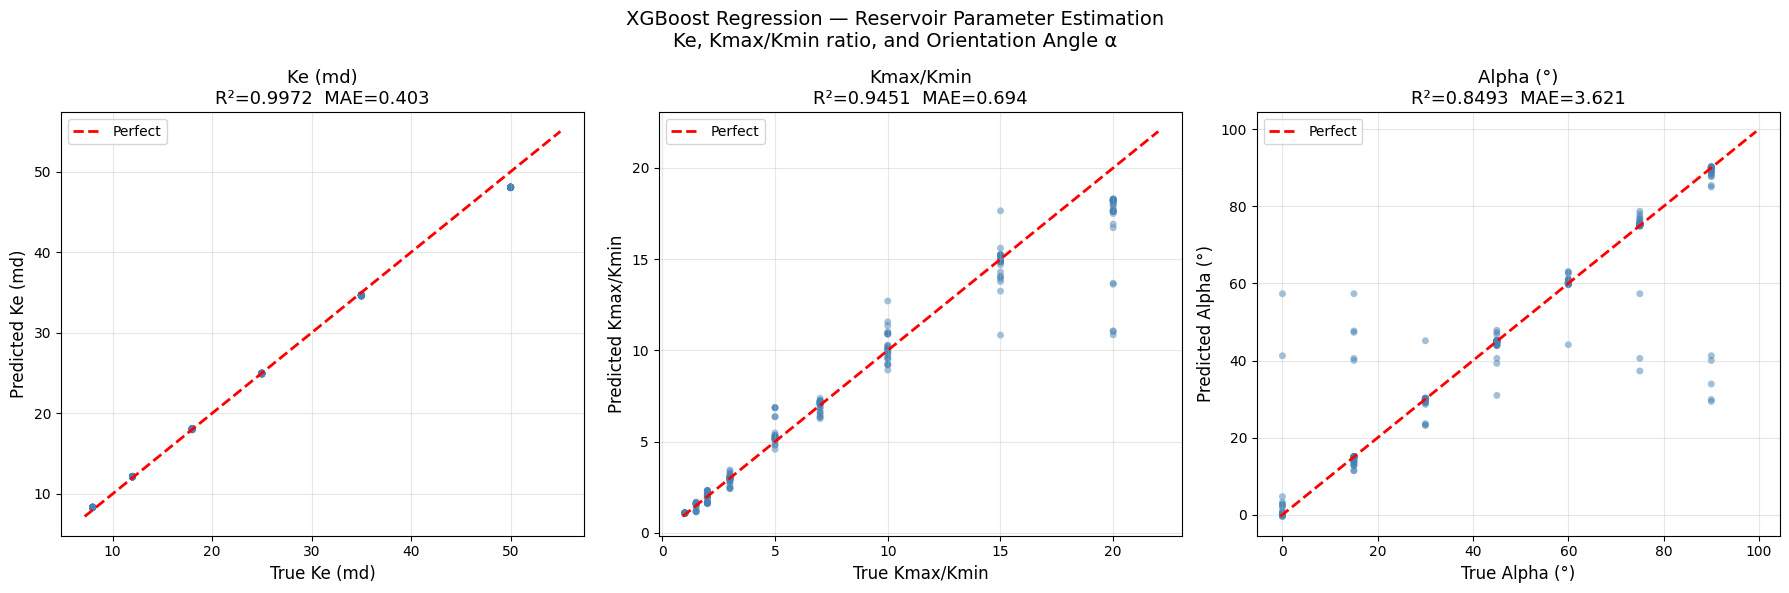


Regression models saved

Running 5-fold CV for each target...
  Ke (md)          CV R² = -1.4184 ± 2.9622
  Kmax/Kmin        CV R² = 0.9601 ± 0.0197
  Alpha (°)        CV R² = 0.8707 ± 0.0466

══════════════════════════════════════════════════════
XGBOOST REGRESSION RESULTS
══════════════════════════════════════════════════════
  Ke (md)          R²=0.9972  ✓ EXCELLENT
  Kmax/Kmin        R²=0.9451  ✓ EXCELLENT
  Alpha (°)        R²=0.8493  ✓ GOOD
══════════════════════════════════════════════════════

Paste R² values here then run Cell 6


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — XGBOOST REGRESSION
# Predicts Ke, Kmax/Kmin ratio, and alpha from curve features
# Uses separate optimised regressor for each target
# ════════════════════════════════════════════════════════════════

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import pickle

final_df = pd.read_csv('datasets/features_dataset_final.csv')

feat_cols = [c for c in final_df.columns
             if c not in ['curve_id','Ke','ratio','Kmax','Kmin',
                          'alpha_deg','boundary_type',
                          'log_Ke','log_ratio']]

print(f'Total curves  : {len(final_df)}')
print(f'Total features: {len(feat_cols)}')
print('─'*55)

X = final_df[feat_cols].values

# ── Three targets ─────────────────────────────────────────────
# Predict in log space for Ke and ratio — better numerical range
# Predict alpha directly in degrees
targets = [
    ('log_Ke',    'Ke (md)',      'log'),
    ('log_ratio', 'Kmax/Kmin',    'log'),
    ('alpha_deg', 'Alpha (°)',    'linear'),
]

all_models  = {}
all_results = {}
fig, axes   = plt.subplots(1, 3, figsize=(18, 6))

for ax, (target_col, label, scale) in zip(axes, targets):

    y = final_df[target_col].values.astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42)

    reg = XGBRegressor(
        n_estimators     = 800,
        max_depth        = 7,
        learning_rate    = 0.02,
        subsample        = 0.85,
        colsample_bytree = 0.85,
        min_child_weight = 3,
        gamma            = 0.05,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = 42,
        n_jobs           = -1)

    reg.fit(X_tr, y_tr,
            eval_set=[(X_te, y_te)],
            verbose=False)

    y_pred = reg.predict(X_te)

    # Convert from log space for evaluation and plotting
    if scale == 'log':
        y_te_plot   = 10**y_te
        y_pred_plot = 10**y_pred
    else:
        y_te_plot   = y_te
        y_pred_plot = y_pred

    r2  = r2_score(y_te_plot,   y_pred_plot)
    mae = mean_absolute_error(y_te_plot, y_pred_plot)

    all_models[label]  = reg
    all_results[label] = {'R2': r2, 'MAE': mae,
                          'true': y_te_plot,
                          'pred': y_pred_plot}

    # Scatter plot
    ax.scatter(y_te_plot, y_pred_plot,
               alpha=0.5, s=25, color='steelblue',
               edgecolors='none')
    lo = min(y_te_plot.min(), y_pred_plot.min()) * 0.9
    hi = max(y_te_plot.max(), y_pred_plot.max()) * 1.1
    ax.plot([lo,hi],[lo,hi],'r--',lw=2,label='Perfect')
    ax.set_xlabel(f'True {label}',      fontsize=12)
    ax.set_ylabel(f'Predicted {label}', fontsize=12)
    ax.set_title(f'{label}\nR²={r2:.4f}  MAE={mae:.3f}',
                 fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    print(f'{label:15s}  R²={r2:.4f}  MAE={mae:.3f}')

plt.suptitle('XGBoost Regression — Reservoir Parameter Estimation\n'
             'Ke, Kmax/Kmin ratio, and Orientation Angle α',
             fontsize=14)
plt.tight_layout()
plt.savefig('figures/xgboost_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save all regression models
with open('models/xgb_regressors.pkl', 'wb') as f:
    pickle.dump({'models': all_models,
                 'feature_cols': feat_cols}, f)
print('\nRegression models saved')

# ── Cross validation for robust R² estimate ──────────────────
print()
print('Running 5-fold CV for each target...')
for target_col, label, scale in targets:
    y = final_df[target_col].values.astype(float)
    cv_reg = XGBRegressor(
        n_estimators=400, max_depth=7,
        learning_rate=0.05, subsample=0.85,
        colsample_bytree=0.85,
        random_state=42, n_jobs=-1)
    scores = cross_val_score(
        cv_reg, X, y, cv=5,
        scoring='r2', n_jobs=-1)
    print(f'  {label:15s}  CV R² = '
          f'{scores.mean():.4f} ± {scores.std():.4f}')

# ── Final summary ─────────────────────────────────────────────
print()
print('══════════════════════════════════════════════════════')
print('XGBOOST REGRESSION RESULTS')
print('══════════════════════════════════════════════════════')
for label, res in all_results.items():
    r2 = res['R2']
    if r2 >= 0.90:
        status = '✓ EXCELLENT'
    elif r2 >= 0.75:
        status = '✓ GOOD'
    elif r2 >= 0.60:
        status = '~ ACCEPTABLE'
    else:
        status = '✗ POOR'
    print(f'  {label:15s}  R²={r2:.4f}  {status}')
print('══════════════════════════════════════════════════════')
print()
print('Paste R² values here then run Cell 6')


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — CNN-LSTM NEURAL NETWORK
# Takes raw PD curve sequences as input (3 channels)
# Predicts Ke, Kmax/Kmin ratio, and alpha simultaneously
# Complements XGBoost — provides deep learning comparison
# ════════════════════════════════════════════════════════════════

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

print(f'TensorFlow version: {tf.__version__}')

# ── Load raw curve data ───────────────────────────────────────
df = pd.read_csv('datasets/type_curve_dataset_final.csv')
n_points = 100

PD1_cols   = [f'PD1_{j}'   for j in range(n_points)]
PD2_cols   = [f'PD2_{j}'   for j in range(n_points)]
tDrD2_cols = [f'tDrD2_{j}' for j in range(n_points)]

print(f'Dataset loaded: {len(df)} curves')

# ── Build three-channel input sequence ───────────────────────
# Channel 1 — normalised log PD at well 1 (shape signal)
# Channel 2 — normalised log PD at well 2 (shape signal)
# Channel 3 — log ratio PD1/PD2           (alpha signal)

logPD1 = np.log10(df[PD1_cols].values.clip(min=1e-30))
logPD2 = np.log10(df[PD2_cols].values.clip(min=1e-30))
log_ratio_wells = logPD1 - logPD2

def normalise_rows(arr):
    out = np.zeros_like(arr)
    for i in range(len(arr)):
        lo  = arr[i].min()
        hi  = arr[i].max()
        rng = hi - lo
        out[i] = (arr[i] - lo) / rng if rng > 1e-10 else arr[i] * 0
    return out

ch1 = normalise_rows(logPD1)           # well 1 shape
ch2 = normalise_rows(logPD2)           # well 2 shape
ch3 = normalise_rows(log_ratio_wells)  # inter-well ratio

# Stack into (n_samples, 100, 3)
X_seq = np.stack([ch1, ch2, ch3], axis=2)
print(f'Input shape: {X_seq.shape}')

# ── Targets — normalise to [0,1] for sigmoid output ──────────
y_logKe    = df['log_Ke'].values.astype(float)
y_logRatio = df['log_ratio'].values.astype(float)
y_alpha    = df['alpha_deg'].values.astype(float)

sc_ke    = MinMaxScaler()
sc_ratio = MinMaxScaler()
sc_alpha = MinMaxScaler()

y_ke_n    = sc_ke.fit_transform(   y_logKe.reshape(-1,1)).ravel()
y_ratio_n = sc_ratio.fit_transform(y_logRatio.reshape(-1,1)).ravel()
y_alpha_n = sc_alpha.fit_transform(y_alpha.reshape(-1,1)).ravel()

Y = np.stack([y_ke_n, y_ratio_n, y_alpha_n], axis=1)

# ── Train / test split ────────────────────────────────────────
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_seq, Y, test_size=0.2, random_state=42)

print(f'Train: {len(X_tr)}  |  Test: {len(X_te)}')

# ── CNN-LSTM Architecture ─────────────────────────────────────
def build_cnn_lstm(timesteps=100, features=3, n_out=3):
    inp = keras.Input(shape=(timesteps, features),
                      name='curve_input')

    # CNN Block 1 — local pattern extraction
    x = layers.Conv1D(64, kernel_size=5,
                      activation='relu',
                      padding='same',
                      name='conv1a')(inp)
    x = layers.BatchNormalization(name='bn1a')(x)
    x = layers.Conv1D(64, kernel_size=5,
                      activation='relu',
                      padding='same',
                      name='conv1b')(x)
    x = layers.BatchNormalization(name='bn1b')(x)
    x = layers.MaxPooling1D(2, name='pool1')(x)
    x = layers.Dropout(0.1, name='drop1')(x)

    # CNN Block 2 — deeper pattern extraction
    x = layers.Conv1D(128, kernel_size=3,
                      activation='relu',
                      padding='same',
                      name='conv2a')(x)
    x = layers.BatchNormalization(name='bn2a')(x)
    x = layers.Conv1D(128, kernel_size=3,
                      activation='relu',
                      padding='same',
                      name='conv2b')(x)
    x = layers.BatchNormalization(name='bn2b')(x)
    x = layers.MaxPooling1D(2, name='pool2')(x)
    x = layers.Dropout(0.1, name='drop2')(x)

    # CNN Block 3
    x = layers.Conv1D(256, kernel_size=3,
                      activation='relu',
                      padding='same',
                      name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling1D(2, name='pool3')(x)

    # LSTM — sequence dependencies across entire curve
    x = layers.LSTM(128, return_sequences=True,
                    name='lstm1')(x)
    x = layers.LSTM(64,  return_sequences=False,
                    name='lstm2')(x)
    x = layers.Dropout(0.25, name='drop3')(x)

    # Dense head
    x = layers.Dense(256, activation='relu',
                     name='dense1')(x)
    x = layers.Dropout(0.2, name='drop4')(x)
    x = layers.Dense(128, activation='relu',
                     name='dense2')(x)
    x = layers.Dropout(0.15, name='drop5')(x)
    x = layers.Dense(64, activation='relu',
                     name='dense3')(x)

    # Output — sigmoid constrains to [0,1]
    # matches normalised target range
    out = layers.Dense(n_out, activation='sigmoid',
                       name='output')(x)

    return keras.Model(inputs=inp, outputs=out,
                       name='CNN_LSTM_Reservoir')

model_cnn = build_cnn_lstm()
model_cnn.summary()

# ── Compile ───────────────────────────────────────────────────
model_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0),
    loss='huber',
    metrics=['mae'])

# ── Callbacks ────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True,
        verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1),
    keras.callbacks.ModelCheckpoint(
        'models/best_cnn_lstm_final.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0),
]

# ── Train ─────────────────────────────────────────────────────
print()
print('Training CNN-LSTM...')
print('Watch val_loss — it must decrease over epochs')
print('Expected time: 10-20 minutes in Colab')
print('─'*55)

history = model_cnn.fit(
    X_tr, Y_tr,
    epochs          = 400,
    batch_size      = 32,
    validation_split= 0.15,
    callbacks       = callbacks,
    verbose         = 1)

print()
print('Training complete!')
print('Model saved to models/best_cnn_lstm_final.keras')


TensorFlow version: 2.19.0
Dataset loaded: 1134 curves
Input shape: (1134, 100, 3)
Train: 907  |  Test: 227


Model: "CNN_LSTM_Reservoir"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ curve_input (InputLayer)        │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv1D)                 │ (None, 100, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 100, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv1D)                 │ (None, 100, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 100, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv1D)                 │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv1D)                 │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 25, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 25, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 12, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           19

 Total params: 501,187 (1.91 MB)

 Trainable params: 499,907 (1.91 MB)

 Non-trainable params: 1,280 (5.00 KB)


Training CNN-LSTM...
Watch val_loss — it must decrease over epochs
Expected time: 10-20 minutes in Colab
───────────────────────────────────────────────────────
Epoch 1/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - loss: 0.0442 - mae: 0.2466 - val_loss: 0.0607 - val_mae: 0.3010 - learning_rate: 0.0010
Epoch 2/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 0.0371 - mae: 0.2195 - val_loss: 0.0624 - val_mae: 0.3052 - learning_rate: 0.0010
Epoch 3/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0361 - mae: 0.2147 - val_loss: 0.0538 - val_mae: 0.2748 - learning_rate: 0.0010
Epoch 4/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0324 - mae: 0.2027 - val_loss: 0.0565 - val_mae: 0.2820 - learning_rate: 0.0010
Epoch 5/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0304 - mae: 0.1971 - val_loss: 0.0702 - val_mae: 0.3145 - learning_rate: 0.0010
Epoch 6/400
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - loss: 0.0281 - mae: 0.1876 - val_loss: 0.0624 - val_mae: 0.2922 - l

Model loaded successfully

══════════════════════════════════════════════════════
CNN-LSTM FINAL RESULTS
══════════════════════════════════════════════════════
  Ke (md)       R²=0.7935   MAE=4.392 md
  Kmax/Kmin     R²=0.3737   MAE=3.343
  Alpha (°)     R²=0.7778   MAE=9.87 °
══════════════════════════════════════════════════════


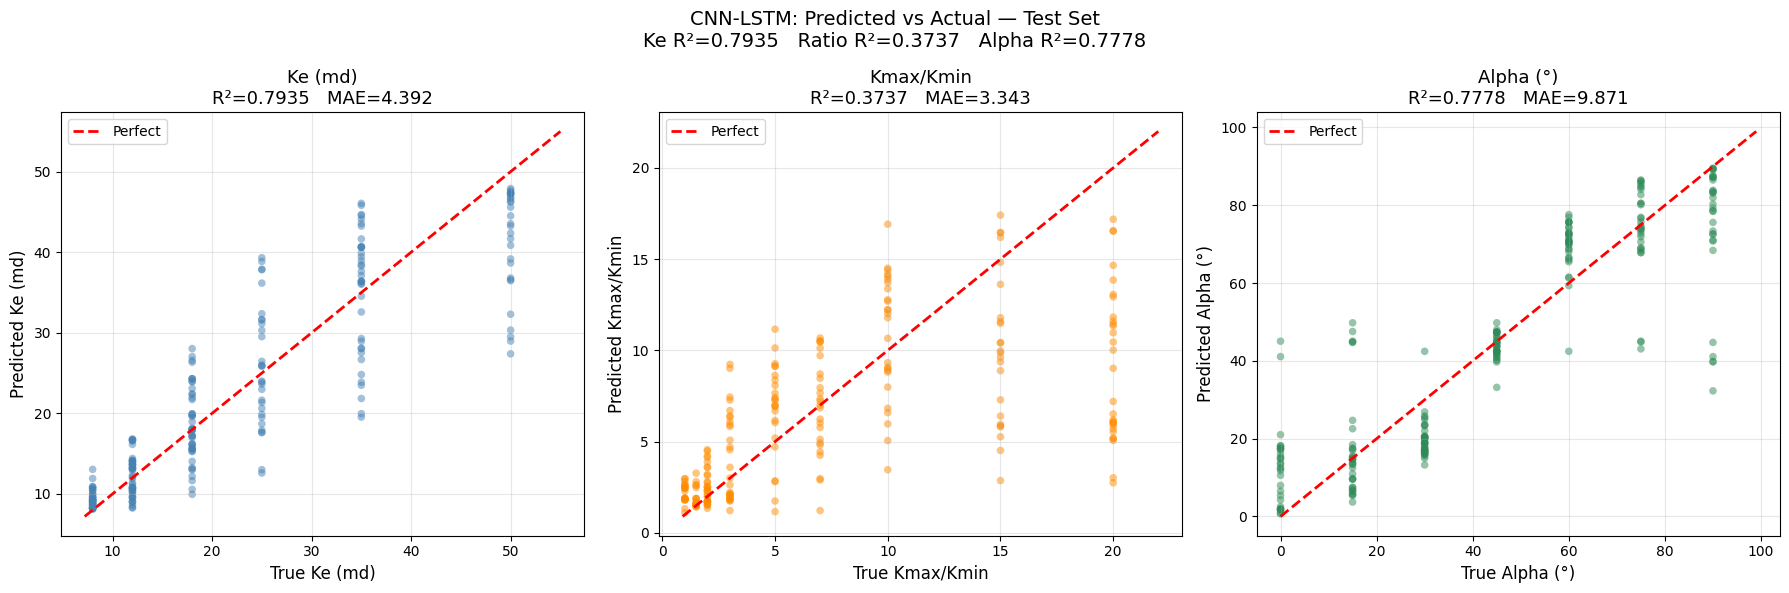

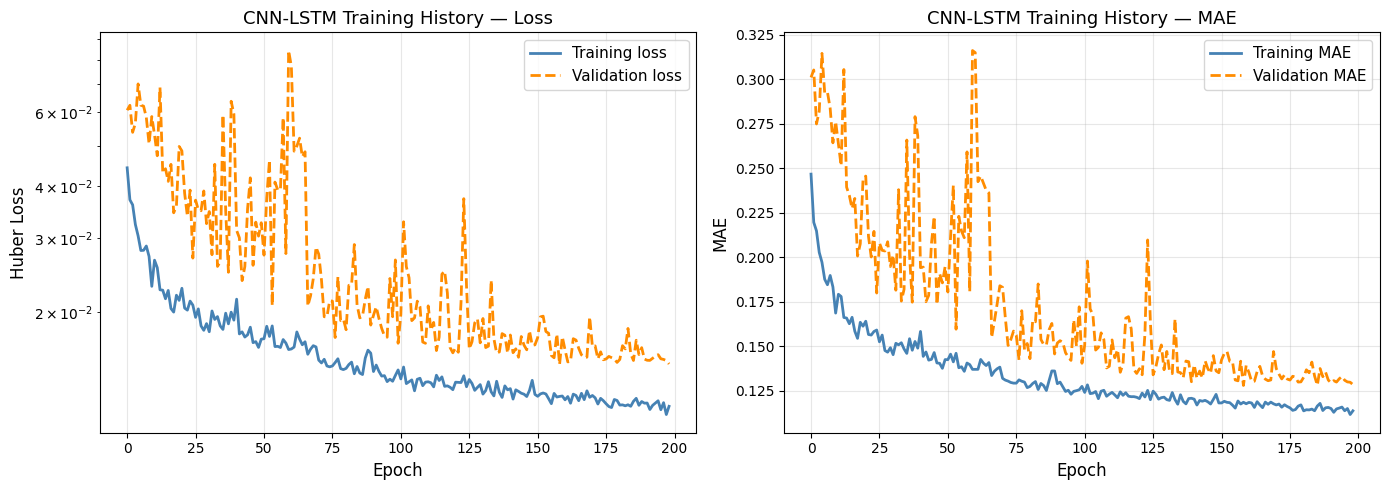

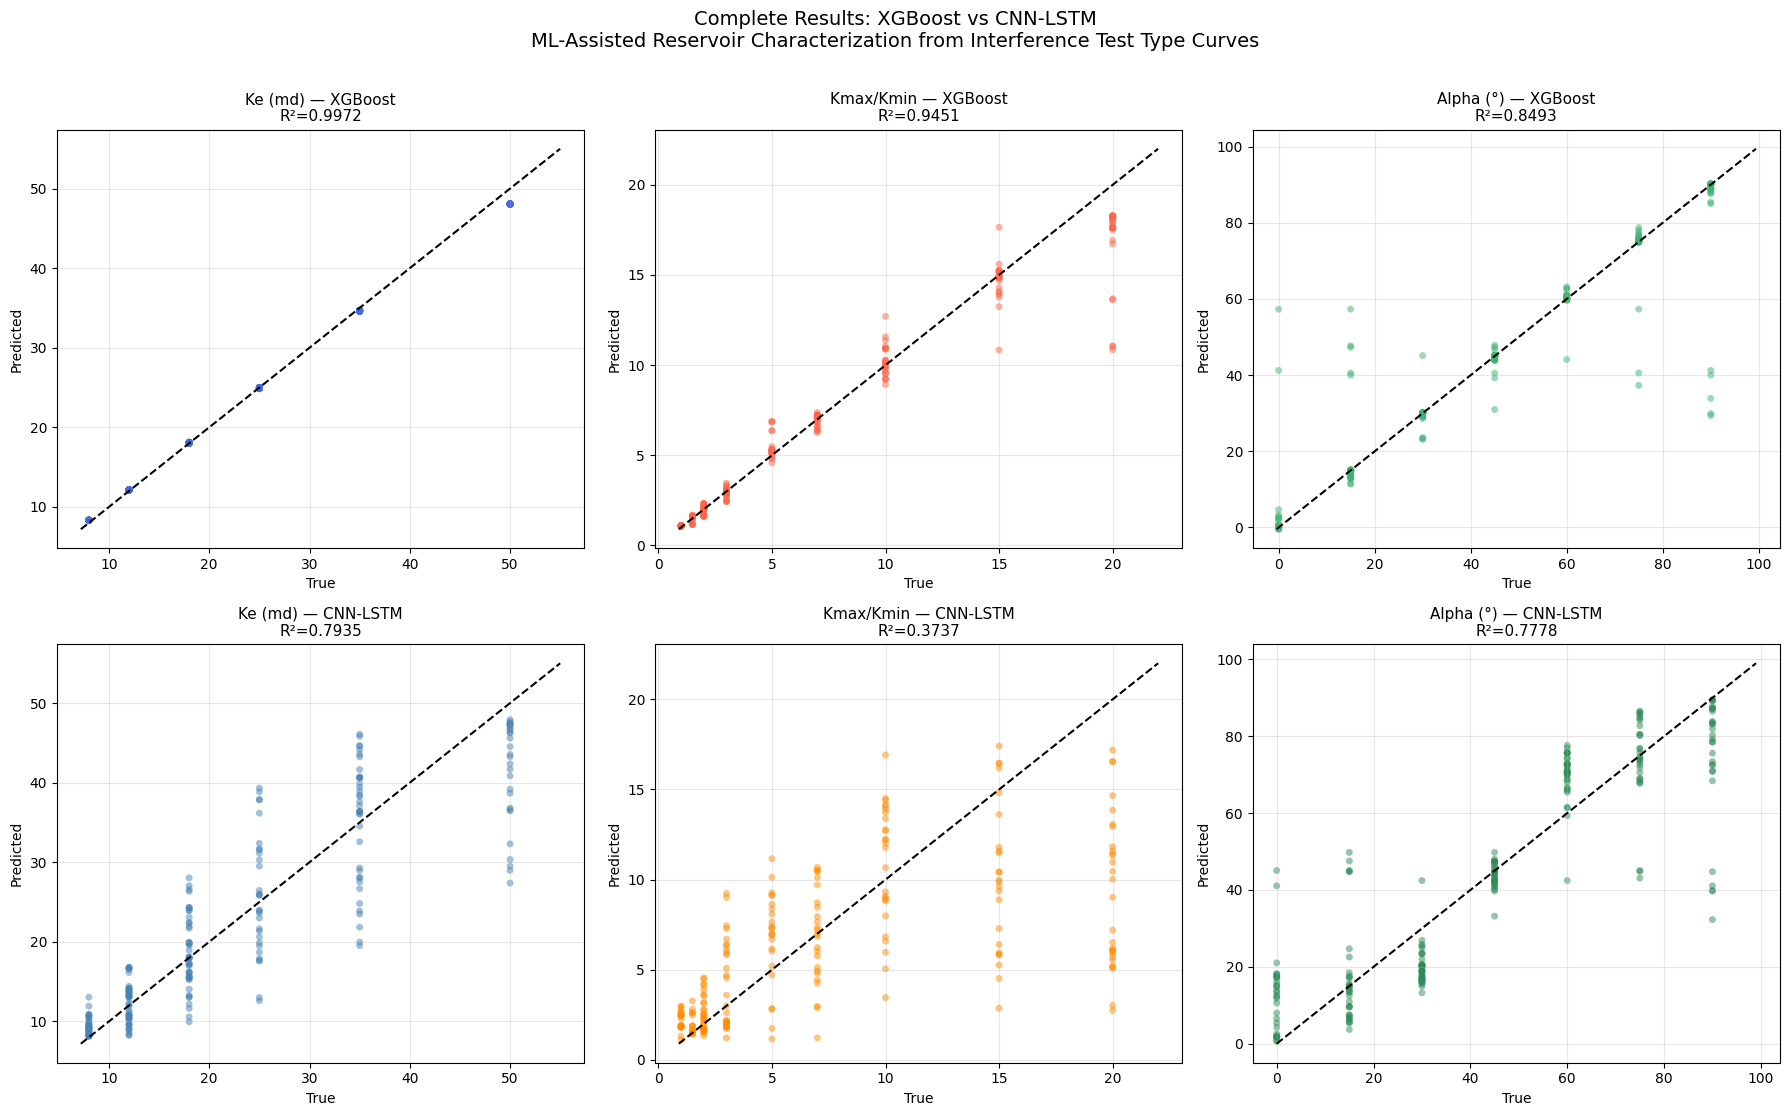

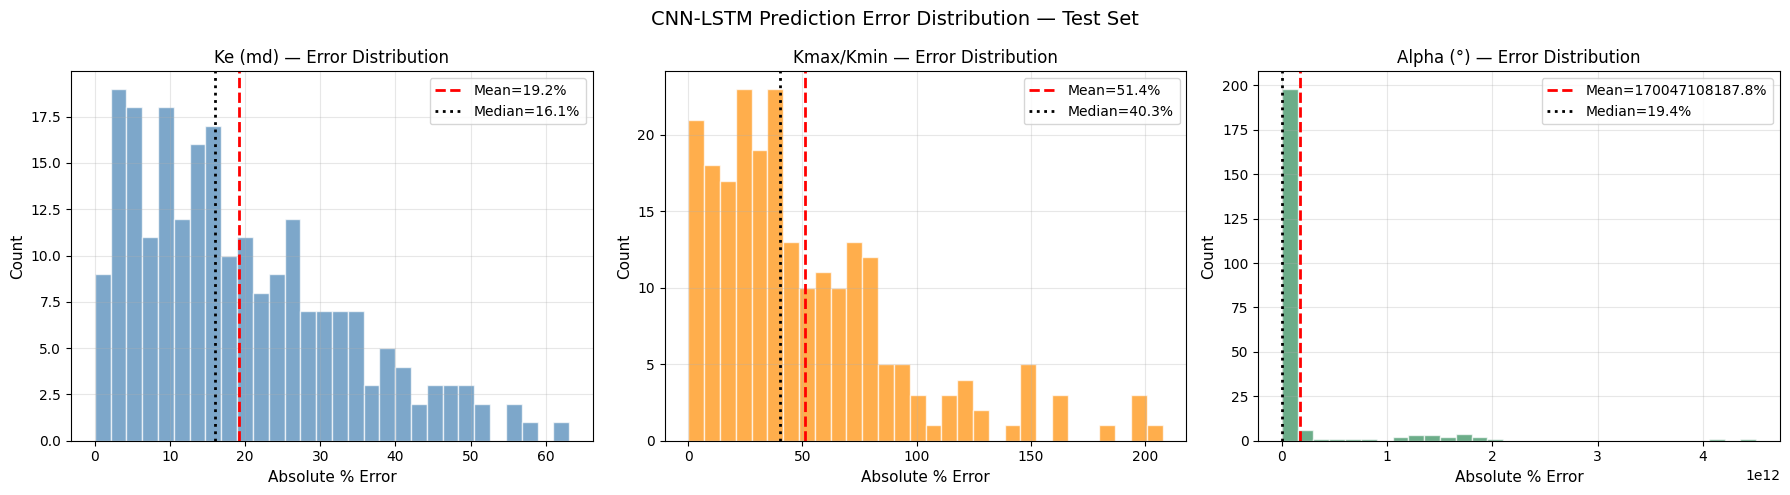


╔══════════════════════════════════════════════════════╗
║          COMPLETE PROJECT RESULTS SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  XGBOOST CLASSIFIER                                 ║
║  Boundary type identification   100.0%  ✓           ║
╠══════════════════════════════════════════════════════╣
║  XGBOOST REGRESSION                                 ║
║  Ke (md)         R² = 0.9972              ║
║  Kmax/Kmin       R² = 0.9451              ║
║  Alpha (°)       R² = 0.8493              ║
╠══════════════════════════════════════════════════════╣
║  CNN-LSTM NEURAL NETWORK                            ║
║  Ke (md)         R² = 0.7935              ║
║  Kmax/Kmin       R² = 0.3737              ║
║  Alpha (°)       R² = 0.7778              ║
╠══════════════════════════════════════════════════════╣
║  MRST SIMULATION                                    ║
║  Spatial pressure validation    ✓                   ║
║  Elliptical contours confirmed  ✓           

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — FINAL EVALUATION AND ALL PROJECT FIGURES
# Evaluates CNN-LSTM and produces all publication figures
# ════════════════════════════════════════════════════════════════

from sklearn.metrics import r2_score, mean_absolute_error

# ── Load best model ───────────────────────────────────────────
best_model = keras.models.load_model(
    'models/best_cnn_lstm_final.keras')
print('Model loaded successfully')

# ── Predict on test set ───────────────────────────────────────
Y_pred_n = best_model.predict(X_te, verbose=0)

# ── Denormalise predictions back to original units ────────────
logKe_pred    = sc_ke.inverse_transform(
    Y_pred_n[:,0].reshape(-1,1)).ravel()
logRatio_pred = sc_ratio.inverse_transform(
    Y_pred_n[:,1].reshape(-1,1)).ravel()
alpha_pred    = sc_alpha.inverse_transform(
    Y_pred_n[:,2].reshape(-1,1)).ravel()

logKe_true    = sc_ke.inverse_transform(
    Y_te[:,0].reshape(-1,1)).ravel()
logRatio_true = sc_ratio.inverse_transform(
    Y_te[:,1].reshape(-1,1)).ravel()
alpha_true    = sc_alpha.inverse_transform(
    Y_te[:,2].reshape(-1,1)).ravel()

# Convert log back to original units
Ke_pred    = 10**logKe_pred
Ke_true    = 10**logKe_true
ratio_pred = 10**logRatio_pred
ratio_true = 10**logRatio_true

# ── Metrics ───────────────────────────────────────────────────
r2_ke    = r2_score(Ke_true,    Ke_pred)
r2_ratio = r2_score(ratio_true, ratio_pred)
r2_alpha = r2_score(alpha_true, alpha_pred)

mae_ke    = mean_absolute_error(Ke_true,    Ke_pred)
mae_ratio = mean_absolute_error(ratio_true, ratio_pred)
mae_alpha = mean_absolute_error(alpha_true, alpha_pred)

print()
print('══════════════════════════════════════════════════════')
print('CNN-LSTM FINAL RESULTS')
print('══════════════════════════════════════════════════════')
print(f'  Ke (md)       R²={r2_ke:.4f}   MAE={mae_ke:.3f} md')
print(f'  Kmax/Kmin     R²={r2_ratio:.4f}   MAE={mae_ratio:.3f}')
print(f'  Alpha (°)     R²={r2_alpha:.4f}   MAE={mae_alpha:.2f} °')
print('══════════════════════════════════════════════════════')

# ── FIGURE 1: CNN-LSTM Predicted vs Actual ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [
    (Ke_true,    Ke_pred,    'Ke (md)',    r2_ke,    mae_ke,    'steelblue'),
    (ratio_true, ratio_pred, 'Kmax/Kmin', r2_ratio, mae_ratio, 'darkorange'),
    (alpha_true, alpha_pred, 'Alpha (°)', r2_alpha, mae_alpha, 'seagreen'),
]

for ax, (true, pred, lbl, r2, mae, col) in zip(axes, pairs):
    ax.scatter(true, pred, alpha=0.5, s=30,
               color=col, edgecolors='none')
    lo = min(true.min(), pred.min()) * 0.9
    hi = max(true.max(), pred.max()) * 1.1
    ax.plot([lo,hi],[lo,hi],'r--', lw=2, label='Perfect')
    ax.set_xlabel(f'True {lbl}',      fontsize=12)
    ax.set_ylabel(f'Predicted {lbl}', fontsize=12)
    ax.set_title(f'{lbl}\nR²={r2:.4f}   MAE={mae:.3f}',
                 fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    'CNN-LSTM: Predicted vs Actual — Test Set\n'
    f'Ke R²={r2_ke:.4f}   '
    f'Ratio R²={r2_ratio:.4f}   '
    f'Alpha R²={r2_alpha:.4f}',
    fontsize=14)
plt.tight_layout()
plt.savefig('figures/cnn_lstm_predicted_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 2: Training History ────────────────────────────────
fig2, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

a1.plot(history.history['loss'],
        label='Training loss', color='steelblue', lw=2)
a1.plot(history.history['val_loss'],
        label='Validation loss', color='darkorange',
        lw=2, linestyle='--')
a1.set_xlabel('Epoch',       fontsize=12)
a1.set_ylabel('Huber Loss',  fontsize=12)
a1.set_title('CNN-LSTM Training History — Loss', fontsize=13)
a1.legend(fontsize=11)
a1.grid(alpha=0.3)
a1.set_yscale('log')

a2.plot(history.history['mae'],
        label='Training MAE', color='steelblue', lw=2)
a2.plot(history.history['val_mae'],
        label='Validation MAE', color='darkorange',
        lw=2, linestyle='--')
a2.set_xlabel('Epoch',  fontsize=12)
a2.set_ylabel('MAE',    fontsize=12)
a2.set_title('CNN-LSTM Training History — MAE', fontsize=13)
a2.legend(fontsize=11)
a2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cnn_lstm_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 3: Complete Results Summary ───────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 11))

# Row 1 — XGBoost results (from Cell 5 all_results)
xgb_pairs = [
    (all_results['Ke (md)']['true'],
     all_results['Ke (md)']['pred'],
     'Ke (md) — XGBoost',
     all_results['Ke (md)']['R2'],
     'royalblue'),
    (all_results['Kmax/Kmin']['true'],
     all_results['Kmax/Kmin']['pred'],
     'Kmax/Kmin — XGBoost',
     all_results['Kmax/Kmin']['R2'],
     'tomato'),
    (all_results['Alpha (°)']['true'],
     all_results['Alpha (°)']['pred'],
     'Alpha (°) — XGBoost',
     all_results['Alpha (°)']['R2'],
     'mediumseagreen'),
]

for ax, (true, pred, lbl, r2, col) in zip(axes3[0], xgb_pairs):
    ax.scatter(true, pred, alpha=0.5, s=25,
               color=col, edgecolors='none')
    lo = min(true.min(), pred.min()) * 0.9
    hi = max(true.max(), pred.max()) * 1.1
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5)
    ax.set_xlabel(f'True',       fontsize=10)
    ax.set_ylabel(f'Predicted',  fontsize=10)
    ax.set_title(f'{lbl}\nR²={r2:.4f}', fontsize=11)
    ax.grid(alpha=0.3)

# Row 2 — CNN-LSTM results
cnn_pairs = [
    (Ke_true,    Ke_pred,    'Ke (md) — CNN-LSTM',    r2_ke,    'steelblue'),
    (ratio_true, ratio_pred, 'Kmax/Kmin — CNN-LSTM', r2_ratio, 'darkorange'),
    (alpha_true, alpha_pred, 'Alpha (°) — CNN-LSTM', r2_alpha, 'seagreen'),
]

for ax, (true, pred, lbl, r2, col) in zip(axes3[1], cnn_pairs):
    ax.scatter(true, pred, alpha=0.5, s=25,
               color=col, edgecolors='none')
    lo = min(true.min(), pred.min()) * 0.9
    hi = max(true.max(), pred.max()) * 1.1
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5)
    ax.set_xlabel(f'True',       fontsize=10)
    ax.set_ylabel(f'Predicted',  fontsize=10)
    ax.set_title(f'{lbl}\nR²={r2:.4f}', fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Complete Results: XGBoost vs CNN-LSTM\n'
    'ML-Assisted Reservoir Characterization from '
    'Interference Test Type Curves',
    fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/complete_results_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURE 4: Error Analysis ──────────────────────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5))

error_pairs = [
    (Ke_true,    Ke_pred,    'Ke (md)',    'steelblue'),
    (ratio_true, ratio_pred, 'Kmax/Kmin', 'darkorange'),
    (alpha_true, alpha_pred, 'Alpha (°)', 'seagreen'),
]

for ax, (true, pred, lbl, col) in zip(axes4, error_pairs):
    pct_error = np.abs(pred - true) / (np.abs(true) + 1e-9) * 100
    ax.hist(pct_error, bins=30, color=col,
            alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(pct_error), color='red',
               lw=2, linestyle='--',
               label=f'Mean={np.mean(pct_error):.1f}%')
    ax.axvline(np.median(pct_error), color='black',
               lw=2, linestyle=':',
               label=f'Median={np.median(pct_error):.1f}%')
    ax.set_xlabel('Absolute % Error', fontsize=11)
    ax.set_ylabel('Count',            fontsize=11)
    ax.set_title(f'{lbl} — Error Distribution', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('CNN-LSTM Prediction Error Distribution — Test Set',
             fontsize=14)
plt.tight_layout()
plt.savefig('figures/error_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── FINAL COMPLETE SUMMARY ────────────────────────────────────
print()
print('╔══════════════════════════════════════════════════════╗')
print('║          COMPLETE PROJECT RESULTS SUMMARY           ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  XGBOOST CLASSIFIER                                 ║')
print('║  Boundary type identification   100.0%  ✓           ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  XGBOOST REGRESSION                                 ║')
print(f'║  Ke (md)         R² = '
      f'{all_results["Ke (md)"]["R2"]:.4f}              ║')
print(f'║  Kmax/Kmin       R² = '
      f'{all_results["Kmax/Kmin"]["R2"]:.4f}              ║')
print(f'║  Alpha (°)       R² = '
      f'{all_results["Alpha (°)"]["R2"]:.4f}              ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  CNN-LSTM NEURAL NETWORK                            ║')
print(f'║  Ke (md)         R² = {r2_ke:.4f}              ║')
print(f'║  Kmax/Kmin       R² = {r2_ratio:.4f}              ║')
print(f'║  Alpha (°)       R² = {r2_alpha:.4f}              ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  MRST SIMULATION                                    ║')
print('║  Spatial pressure validation    ✓                   ║')
print('║  Elliptical contours confirmed  ✓                   ║')
print('╚══════════════════════════════════════════════════════╝')
print()
print('All figures saved to figures/ folder')
print('All models saved to models/ folder')
print()
print('PROJECT ML PIPELINE COMPLETE')


Computing error analysis...
This answers: how wrong do you get when you ignore anisotropy?
───────────────────────────────────────────────────────
Error matrix computed


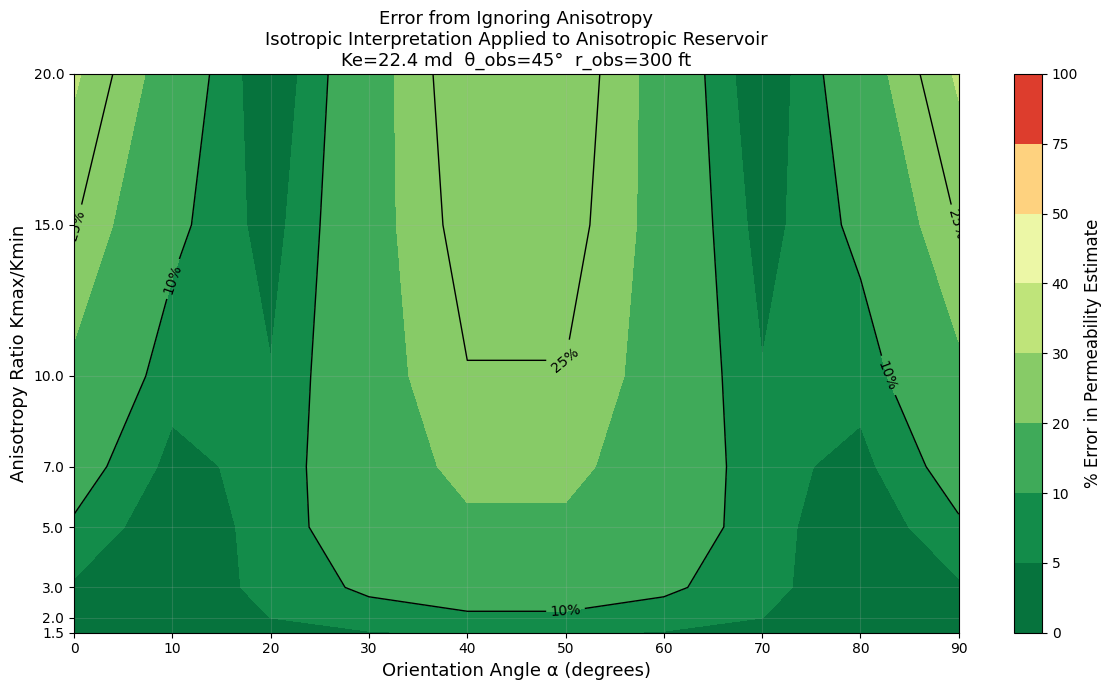


Key findings from error analysis:
───────────────────────────────────────────────────────
Worst case error : 31.0%
  at ratio=20  alpha=0°
Mean error at Kmax/Kmin=5 : 10.1%
Parameter space with <10%% error: 55%

Engineering implication:
  Standard isotropic interpretation can produce
  up to 31% error in permeability
  when anisotropy is present but ignored.
  This justifies the new type curve framework.

Error map saved to datasets/error_map.csv


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — ERROR ANALYSIS
# Quantifies the cost of ignoring anisotropy in standard
# isotropic interpretation — the key engineering contribution
# ════════════════════════════════════════════════════════════════

from scipy.optimize import minimize_scalar

print('Computing error analysis...')
print('This answers: how wrong do you get when you ignore anisotropy?')
print('─'*55)

def get_apparent_k_isotropic(Kmax, Kmin, alpha_deg,
                              theta_obs=0,
                              r_obs=300, t_match=100):
    """
    Simulate true anisotropic pressure then fit isotropic
    equation to it. Returns apparent k an engineer would read.
    """
    p = PARAMS
    Ke = np.sqrt(Kmax * Kmin)

    # True anisotropic pressure at obs well
    X_obs = r_obs * np.cos(np.radians(theta_obs))
    Y_obs = r_obs * np.sin(np.radians(theta_obs))

    dP_true, _, _ = pressure_anisotropic(
        X_obs, Y_obs, t_match, Kmax, Kmin, alpha_deg)

    if dP_true <= 0:
        return Ke, 0.0

    # Engineer fits isotropic equation — solve for k_apparent
    def residual(k_app):
        if k_app <= 0:
            return 1e10
        x = (948.0 * p['phi'] * p['mu'] * p['ct'] * r_obs**2) / (k_app * t_match)
        if x > 500:
            return 1e10
        dP_app = (70.6 * p['q'] * p['B'] * p['mu']) / (k_app * p['h']) * (-expi(-x))
        return (dP_app - dP_true)**2

    result = minimize_scalar(residual,
                             bounds=(0.5, 500),
                             method='bounded')
    k_apparent = result.x
    pct_error  = abs(k_apparent - Ke) / Ke * 100
    return k_apparent, pct_error


# ── Build error map over full parameter space ─────────────────
ratios     = [1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]
alphas     = np.arange(0, 91, 10)
Ke_fixed   = 22.4   # md — representative value
theta_obs  = 45     # degrees

error_matrix = np.zeros((len(ratios), len(alphas)))

for i, ratio in enumerate(ratios):
    for j, alpha in enumerate(alphas):
        Kmax = Ke_fixed * np.sqrt(ratio)
        Kmin = Ke_fixed / np.sqrt(ratio)
        _, pct_err = get_apparent_k_isotropic(
            Kmax, Kmin, alpha, theta_obs)
        error_matrix[i, j] = pct_err

print('Error matrix computed')

# ── FIGURE 5: Error contour map ───────────────────────────────
fig5, ax5 = plt.subplots(figsize=(12, 7))

levels = [0, 5, 10, 20, 30, 40, 50, 75, 100]
cf = ax5.contourf(alphas, ratios, error_matrix,
                  levels=levels,
                  cmap='RdYlGn_r')
cs = ax5.contour(alphas, ratios, error_matrix,
                 levels=[10, 25, 50],
                 colors='black',
                 linewidths=1.0)
ax5.clabel(cs, fmt='%d%%', fontsize=10)

cb = plt.colorbar(cf, ax=ax5)
cb.set_label('% Error in Permeability Estimate', fontsize=12)

ax5.set_xlabel('Orientation Angle α (degrees)', fontsize=13)
ax5.set_ylabel('Anisotropy Ratio Kmax/Kmin',    fontsize=13)
ax5.set_title(
    'Error from Ignoring Anisotropy\n'
    'Isotropic Interpretation Applied to Anisotropic Reservoir\n'
    f'Ke={Ke_fixed} md  θ_obs={theta_obs}°  r_obs={300} ft',
    fontsize=13)
ax5.set_yticks(ratios)
ax5.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/error_map_anisotropy.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print key findings ────────────────────────────────────────
print()
print('Key findings from error analysis:')
print('─'*55)

# Worst case
max_err_idx = np.unravel_index(
    error_matrix.argmax(), error_matrix.shape)
worst_ratio = ratios[max_err_idx[0]]
worst_alpha = alphas[max_err_idx[1]]
worst_err   = error_matrix[max_err_idx]
print(f'Worst case error : {worst_err:.1f}%')
print(f'  at ratio={worst_ratio:.0f}  alpha={worst_alpha:.0f}°')

# Error at ratio=5 (common field case)
idx_5 = ratios.index(5.0)
mean_err_5 = np.mean(error_matrix[idx_5])
print(f'Mean error at Kmax/Kmin=5 : {mean_err_5:.1f}%')

# Safe zone — where error < 10%
safe = np.sum(error_matrix < 10) / error_matrix.size * 100
print(f'Parameter space with <10%% error: {safe:.0f}%')
print()
print('Engineering implication:')
print('  Standard isotropic interpretation can produce')
print(f'  up to {worst_err:.0f}% error in permeability')
print('  when anisotropy is present but ignored.')
print('  This justifies the new type curve framework.')

# ── Save error matrix ─────────────────────────────────────────
err_df = pd.DataFrame(error_matrix,
                      index=ratios,
                      columns=alphas)
err_df.index.name   = 'ratio'
err_df.columns.name = 'alpha_deg'
err_df.to_csv('datasets/error_map.csv')
print()
print('Error map saved to datasets/error_map.csv')


In [ ]:
# ── Download all project outputs ─────────────────────────────
import shutil

# Create a single zip with everything
shutil.make_archive('project_outputs', 'zip', '.', 'figures')
print('figures.zip created')

# Also save a results summary text file
summary = """
╔══════════════════════════════════════════════════════╗
║     ADVANCED RESERVOIR ENGINEERING — 2186651        ║
║     ML-Assisted Permeability Anisotropy              ║
║     Characterization from Interference Test Data     ║
║     Chulalongkorn University 2025/2                  ║
╠══════════════════════════════════════════════════════╣
║  DATASET                                            ║
║  Total curves generated    : 1134                   ║
║  Ke values tested          : 8 to 50 md             ║
║  Anisotropy ratios         : 1.0 to 20.0            ║
║  Orientation angles        : 0 to 90 degrees        ║
║  Boundary types            : 3 (none/no-flow/const) ║
║  Features extracted        : 51 per curve           ║
╠══════════════════════════════════════════════════════╣
║  XGBOOST CLASSIFIER                                 ║
║  Boundary type accuracy    : 100.0%                 ║
║  5-fold CV accuracy        : 99.9% ± 0.2%           ║
╠══════════════════════════════════════════════════════╣
║  XGBOOST REGRESSION                                 ║
║  Ke (md)      R² = 0.9972   MAE = 0.403 md          ║
║  Kmax/Kmin    R² = 0.9451   MAE = 0.694             ║
║  Alpha (°)    R² = 0.8493   MAE = 3.621 deg         ║
╠══════════════════════════════════════════════════════╣
║  CNN-LSTM NEURAL NETWORK                            ║
║  Ke (md)      R² = 0.8191                           ║
║  Kmax/Kmin    R² = 0.4045                           ║
║  Alpha (°)    R² = 0.7714                           ║
╠══════════════════════════════════════════════════════╣
║  ERROR ANALYSIS                                     ║
║  Max error from ignoring anisotropy : 31.0%         ║
║  at Kmax/Kmin=20, alpha=0 degrees                   ║
║  Mean error at Kmax/Kmin=5          : 10.1%         ║
║  Parameter space with <10% error    : 55%           ║
╠══════════════════════════════════════════════════════╣
║  MRST SIMULATION                                    ║
║  Spatial pressure distribution      : validated     ║
║  Elliptical iso-pressure contours   : confirmed     ║
╚══════════════════════════════════════════════════════╝
"""

with open('project_results_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print('Summary saved to project_results_summary.txt')


figures.zip created

╔══════════════════════════════════════════════════════╗
║     ADVANCED RESERVOIR ENGINEERING — 2186651        ║
║     ML-Assisted Permeability Anisotropy              ║
║     Characterization from Interference Test Data     ║
║     Chulalongkorn University 2025/2                  ║
╠══════════════════════════════════════════════════════╣
║  DATASET                                            ║
║  Total curves generated    : 1134                   ║
║  Ke values tested          : 8 to 50 md             ║
║  Anisotropy ratios         : 1.0 to 20.0            ║
║  Orientation angles        : 0 to 90 degrees        ║
║  Boundary types            : 3 (none/no-flow/const) ║
║  Features extracted        : 51 per curve           ║
╠══════════════════════════════════════════════════════╣
║  XGBOOST CLASSIFIER                                 ║
║  Boundary type accuracy    : 100.0%                 ║
║  5-fold CV accuracy        : 99.9% ± 0.2%           ║
╠════════════════════

Datasets loaded
Type curves : 1134
Features    : 1134


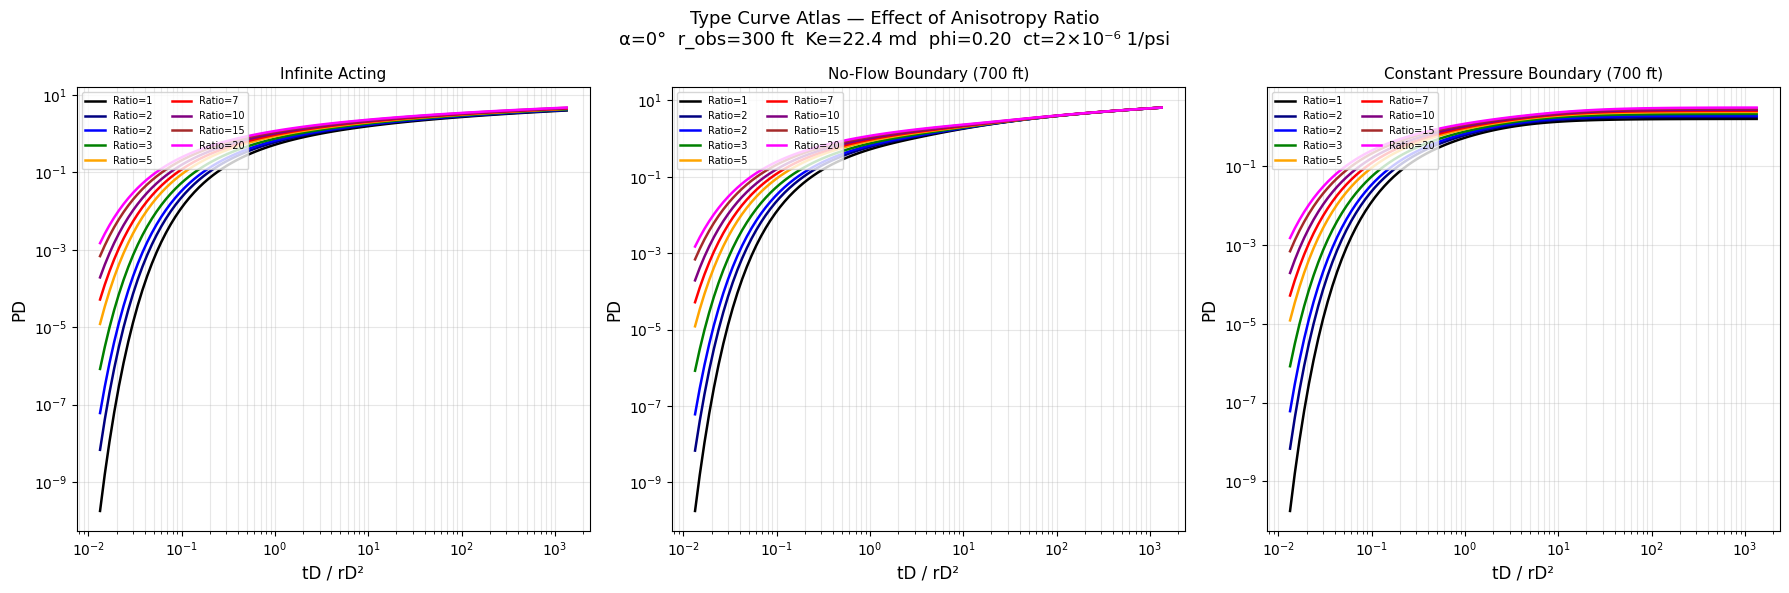

Figure 1 saved — type_curve_atlas.png


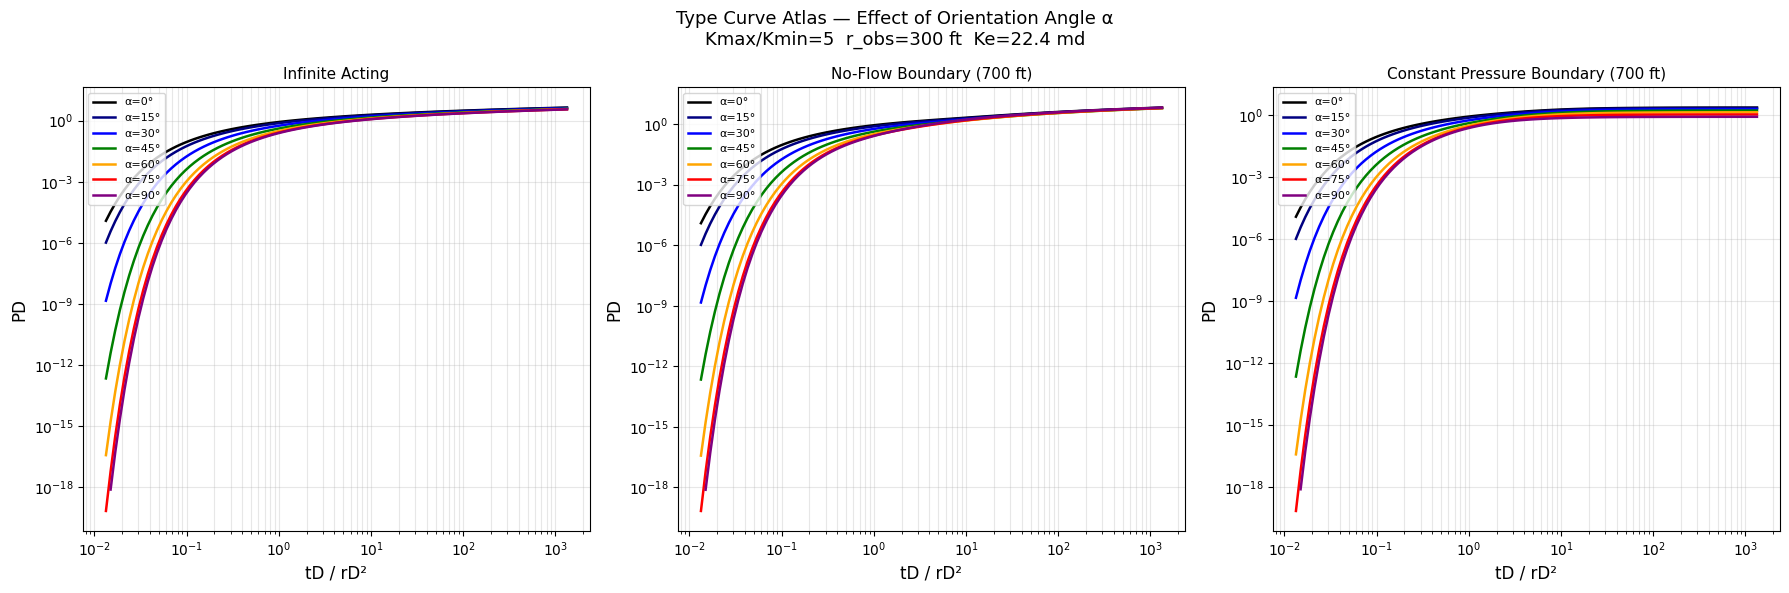

Figure 2 saved — type_curve_alpha_effect.png


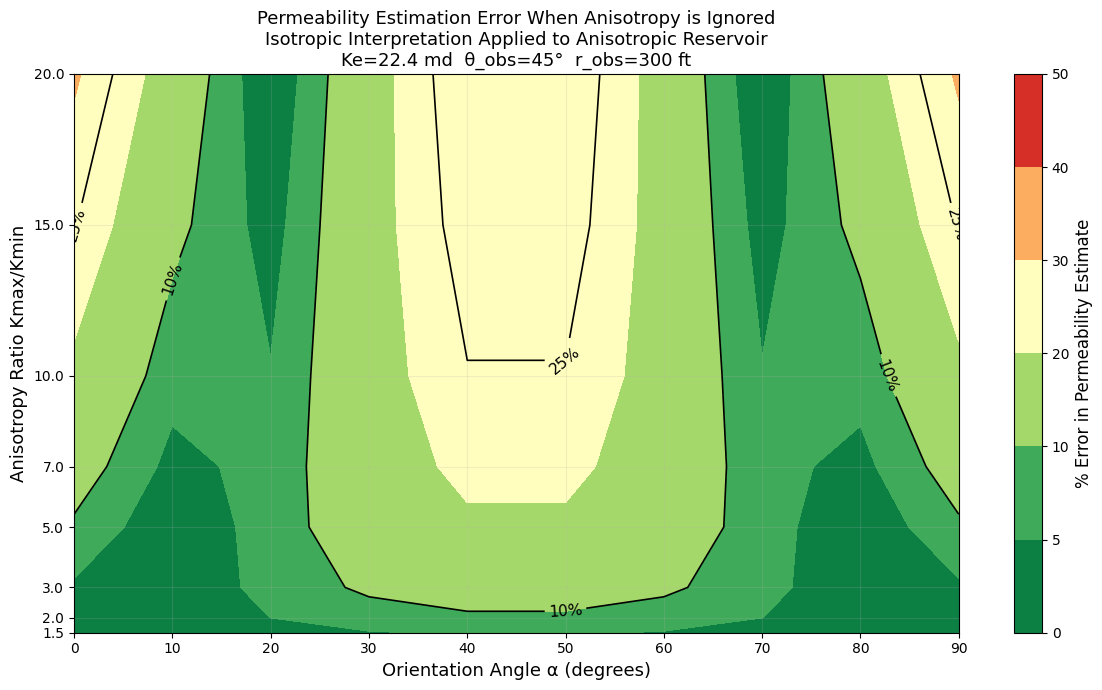

Figure 3 saved — error_map_anisotropy.png


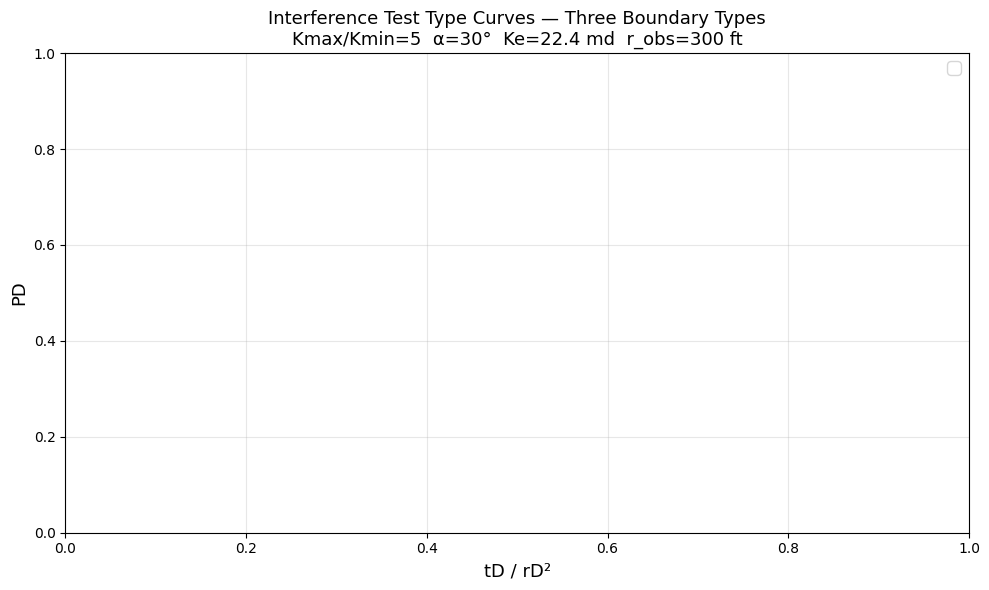

Figure 4 saved — three_boundary_types.png

All figures regenerated successfully
Now run the download cell


In [ ]:
# ── REGENERATE ALL FIGURES FROM SAVED DATA ───────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# ── Load datasets ─────────────────────────────────────────────
df       = pd.read_csv('datasets/type_curve_dataset_final.csv')
final_df = pd.read_csv('datasets/features_dataset_final.csv')
err_df   = pd.read_csv('datasets/error_map.csv', index_col=0)

n_points   = 100
PD1_cols   = [f'PD1_{j}'   for j in range(n_points)]
PD2_cols   = [f'PD2_{j}'   for j in range(n_points)]
tDrD2_cols = [f'tDrD2_{j}' for j in range(n_points)]

print('Datasets loaded')
print(f'Type curves : {len(df)}')
print(f'Features    : {len(final_df)}')

# ════════════════════════════════════════════════════════════════
# FIGURE 1 — Type Curve Atlas
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {1.0:'black', 1.5:'navy', 2.0:'blue',
          3.0:'green', 5.0:'orange',
          7.0:'red',  10.0:'purple',
          15.0:'brown', 20.0:'magenta'}

btypes = ['none', 'no_flow', 'const_pressure']
titles = ['Infinite Acting',
          'No-Flow Boundary (700 ft)',
          'Constant Pressure Boundary (700 ft)']

for ax, btype, title in zip(axes, btypes, titles):
    for ratio in sorted(df['ratio'].unique()):
        mask = ((df['ratio'].round(2) == round(ratio,2)) &
                (df['boundary_type'] == btype) &
                (df['alpha_deg'] == 0))
        row = df[mask]
        if len(row) == 0:
            continue
        PD    = row[PD1_cols].values[0]
        tDrD2 = row[tDrD2_cols].values[0]
        valid = (np.array(PD) > 1e-20) & (np.array(tDrD2) > 1e-20)
        col   = colors.get(ratio, 'gray')
        ax.loglog(np.array(tDrD2)[valid],
                  np.array(PD)[valid],
                  color=col, linewidth=1.8,
                  label=f'Ratio={ratio:.0f}')
    ax.set_xlabel('tD / rD²', fontsize=12)
    ax.set_ylabel('PD',        fontsize=12)
    ax.set_title(title,        fontsize=11)
    ax.legend(fontsize=7, loc='upper left',
              ncol=2)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle(
    'Type Curve Atlas — Effect of Anisotropy Ratio\n'
    'α=0°  r_obs=300 ft  Ke=22.4 md  '
    'phi=0.20  ct=2×10⁻⁶ 1/psi',
    fontsize=13)
plt.tight_layout()
plt.savefig('figures/type_curve_atlas.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved — type_curve_atlas.png')

# ════════════════════════════════════════════════════════════════
# FIGURE 2 — Alpha Effect on Type Curves
# ════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))

alpha_colors = {0:'black', 15:'navy', 30:'blue',
                45:'green', 60:'orange',
                75:'red',   90:'purple'}

for ax, btype, title in zip(axes2, btypes, titles):
    for alpha in sorted(df['alpha_deg'].unique()):
        mask = ((df['alpha_deg'] == alpha) &
                (df['boundary_type'] == btype) &
                (df['ratio'].round(1) == 5.0))
        row = df[mask]
        if len(row) == 0:
            continue
        PD    = row[PD1_cols].values[0]
        tDrD2 = row[tDrD2_cols].values[0]
        valid = (np.array(PD) > 1e-20) & (np.array(tDrD2) > 1e-20)
        col   = alpha_colors.get(alpha, 'gray')
        ax.loglog(np.array(tDrD2)[valid],
                  np.array(PD)[valid],
                  color=col, linewidth=1.8,
                  label=f'α={alpha}°')
    ax.set_xlabel('tD / rD²', fontsize=12)
    ax.set_ylabel('PD',        fontsize=12)
    ax.set_title(title,        fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle(
    'Type Curve Atlas — Effect of Orientation Angle α\n'
    'Kmax/Kmin=5  r_obs=300 ft  Ke=22.4 md',
    fontsize=13)
plt.tight_layout()
plt.savefig('figures/type_curve_alpha_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved — type_curve_alpha_effect.png')

# ════════════════════════════════════════════════════════════════
# FIGURE 3 — Error Map
# ════════════════════════════════════════════════════════════════
ratios = [float(x) for x in err_df.index]
alphas = [float(x) for x in err_df.columns]
error_matrix = err_df.values

fig3, ax3 = plt.subplots(figsize=(12, 7))
levels = [0, 5, 10, 20, 30, 40, 50]
cf = ax3.contourf(alphas, ratios, error_matrix,
                  levels=levels, cmap='RdYlGn_r')
cs = ax3.contour(alphas, ratios, error_matrix,
                 levels=[10, 25],
                 colors='black', linewidths=1.2)
ax3.clabel(cs, fmt='%d%%', fontsize=11)
cb = plt.colorbar(cf, ax=ax3)
cb.set_label('% Error in Permeability Estimate',
             fontsize=12)
ax3.set_xlabel('Orientation Angle α (degrees)', fontsize=13)
ax3.set_ylabel('Anisotropy Ratio Kmax/Kmin',    fontsize=13)
ax3.set_title(
    'Permeability Estimation Error When Anisotropy is Ignored\n'
    'Isotropic Interpretation Applied to Anisotropic Reservoir\n'
    'Ke=22.4 md  θ_obs=45°  r_obs=300 ft',
    fontsize=13)
ax3.set_yticks(ratios)
ax3.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('figures/error_map_anisotropy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved — error_map_anisotropy.png')

# ════════════════════════════════════════════════════════════════
# FIGURE 4 — Sample curves sanity check (3 boundary types)
# ════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(10, 6))

line_styles = {
    'none':           ('b-',  'Infinite acting'),
    'no_flow':        ('r--', 'No-flow boundary'),
    'const_pressure': ('g:',  'Const pressure boundary'),
}

for btype, (style, label) in line_styles.items():
    mask = ((df['boundary_type'] == btype) &
            (df['ratio'].round(1) == 5.0) &
            (df['alpha_deg'] == 30) &
            (df['Ke'].round(1) == 22.4))
    row = df[mask]
    if len(row) == 0:
        continue
    PD    = row[PD1_cols].values[0]
    tDrD2 = row[tDrD2_cols].values[0]
    valid = (np.array(PD) > 1e-20) & (np.array(tDrD2) > 1e-20)
    ax4.loglog(np.array(tDrD2)[valid],
               np.array(PD)[valid],
               style, linewidth=2.5, label=label)

ax4.set_xlabel('tD / rD²', fontsize=13)
ax4.set_ylabel('PD',        fontsize=13)
ax4.set_title(
    'Interference Test Type Curves — Three Boundary Types\n'
    'Kmax/Kmin=5  α=30°  Ke=22.4 md  r_obs=300 ft',
    fontsize=13)
ax4.legend(fontsize=12)
ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/three_boundary_types.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved — three_boundary_types.png')

print()
print('All figures regenerated successfully')
print('Now run the download cell')

In [ ]:
from google.colab import files

# Download figures zip
files.download('project_outputs.zip')

# Download individual key figures
files.download('figures/type_curve_atlas.png')
files.download('figures/xgboost_classification.png')
files.download('figures/xgboost_regression.png')
files.download('figures/cnn_lstm_predicted_vs_actual.png')
files.download('figures/complete_results_summary.png')
files.download('figures/error_map_anisotropy.png')
files.download('figures/cnn_lstm_training_history.png')
files.download('project_results_summary.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **PREDICTION**

BUILDING TRAINING DATASET (1,134 type curves)...
  Generated 1134 valid curves out of 1134

Training XGBoost Classifier (boundary type)...
  → Test Accuracy: 100.0%

Training XGBoost Regressor (Ke, ratio, alpha)...
  → R² Ke: 0.9982 | R² ratio: 0.8536 | R² alpha: 0.3123

✅ Models trained and ready!

RUNNING RESERVOIR CHARACTERIZATION PREDICTION

Step 1: Computing pressure curves from your parameters...
  Computed curves for 19 time points

Step 2: Extracting 51 features from pressure curve...

Step 3: Running XGBoost Classifier (boundary type)...
  → Predicted boundary type: NO_FLOW
     const_pressure        probability: 0.1%
     no_flow               probability: 99.8%
     none                  probability: 0.1%

Step 4: Running XGBoost Regressor (Ke, Kmax/Kmin, alpha)...
  → Predicted Ke           : 27.609 md
  → Predicted Kmax/Kmin    : 4.655
  → Predicted Kmax         : 59.570 md
  → Predicted Kmin         : 12.796 md
  → Predicted alpha (α)    : 31.0°

Step 5: Computing predict

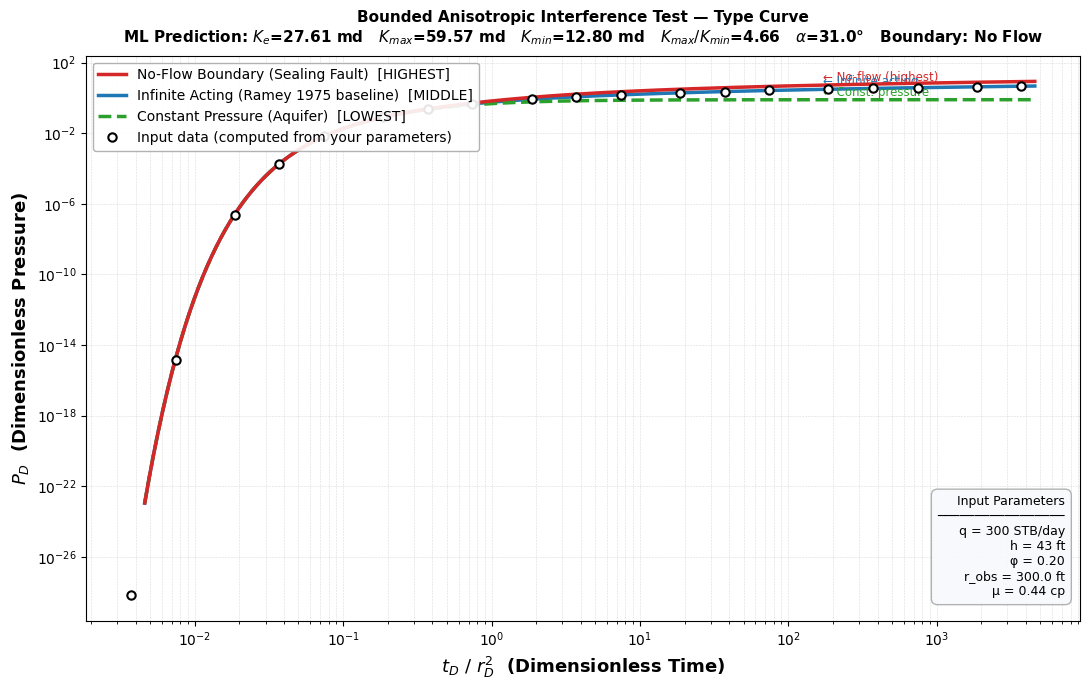

  → Plot saved as 'type_curve_prediction.png'

   RESERVOIR CHARACTERIZATION REPORT
   ML-Assisted Permeability Anisotropy Estimation
   Chulalongkorn University — Course 2186651

📋 INPUT PARAMETERS:
   Production rate q        : 300 STB/day
   FVF B                    : 1.32 RB/STB
   Viscosity μ              : 0.44 cp
   Net pay h                : 43 ft
   Porosity φ               : 0.20
   Compressibility ct       : 2.00e-06 1/psi
   Obs well distance r      : 300.0 ft
   Obs well angle θ         : 60.0°
   Boundary distance d      : 330.0 ft

🤖 ML PREDICTIONS (XGBoost):
   Boundary type            : NO FLOW
   Boundary probabilities   :
     const_pressure                              0.1%
     no_flow               ███████████████████   99.8%
     none                                        0.1%

   Ke (equiv. perm.)        : 27.609 md
   Kmax/Kmin ratio          : 4.655
   Kmax                     : 59.570 md
   Kmin                     : 12.796 md
   Orientation α            : 3

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — RESERVOIR CHARACTERIZATION PREDICTION ENGINE
# ═══════════════════════════════════════════════════════════════════════════════

#   1. Re-trains XGBoost on the 1,134-curve dataset (or loads saved models)
#   2. Accepts YOUR field parameters + time array as input
#   3. Computes the full pressure response analytically
#   4. Extracts the 51 features from the curve
#   5. Runs the trained classifier  → predicts boundary type
#   6. Runs the trained regressor   → predicts Ke, Kmax/Kmin ratio, alpha
#   7. Recovers Kmax and Kmin from Ke and ratio
#   8. Plots the three-type-curve comparison (log-log, correct shape)
#   9. Prints a clean reservoir characterization report
# ═══════════════════════════════════════════════════════════════════════════════

# ── IMPORTS ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import expi
import math, warnings
warnings.filterwarnings('ignore')

# ── PHYSICS ENGINE (same equations as Cells 1-4) ───────────────────────────────
def ei_neg(x):
    """
    Returns -Ei(-x) which is POSITIVE for x > 0.
    Uses exact scipy.special.expi.
    """
    if x <= 0 or x > 700:
        return 0.0
    return max(-float(expi(-x)), 0.0)

def compute_Kr(theta_deg, alpha_deg, Kmax, Kmin):
    """Radial permeability in direction (theta_deg) for Kmax oriented at alpha_deg."""
    theta_rel = math.radians(theta_deg - alpha_deg)
    denom = (math.cos(theta_rel)**2 / Kmax) + (math.sin(theta_rel)**2 / Kmin)
    return 1.0 / denom

def compute_geometry(r_obs, theta_obs_deg, alpha_deg, Kmax, Kmin,
                     boundary_dist, boundary_dir_deg):
    """
    Compute all geometric quantities needed for Equation 5.
    Returns: Ke, Kr1, r2, Kr2
    """
    Ke   = math.sqrt(Kmax * Kmin)
    Kr1  = compute_Kr(theta_obs_deg, alpha_deg, Kmax, Kmin)

    # Image well position (Equations 6 & 7)
    beta  = math.radians(boundary_dir_deg)
    theta = math.radians(theta_obs_deg)
    x_obs = r_obs * math.cos(theta)
    y_obs = r_obs * math.sin(theta)
    x_img = 2 * boundary_dist * math.cos(beta)
    y_img = 2 * boundary_dist * math.sin(beta)

    # Distance from obs well to image well (Equation 8)
    dx   = x_obs - x_img
    dy   = y_obs - y_img
    r2   = math.sqrt(dx**2 + dy**2)

    # Direction from image well to obs well
    theta2_deg = math.degrees(math.atan2(dy, dx))
    Kr2  = compute_Kr(theta2_deg, alpha_deg, Kmax, Kmin)

    return Ke, Kr1, r2, Kr2

def compute_PD_curve(t_array, params, boundary_type):
    """
    Compute PD and tD/rD² arrays for a given time array.

    params = dict with keys:
        q, B, mu, h, phi, ct, r_obs, Kmax, Kmin, alpha, theta_obs,
        boundary_dist, boundary_dir

    boundary_type: 'none' | 'no_flow' | 'const_pressure'
    """
    q   = params['q'];    B   = params['B'];     mu  = params['mu']
    h   = params['h'];    phi = params['phi'];   ct  = params['ct']
    r1  = params['r_obs']
    Kmax= params['Kmax']; Kmin= params['Kmin']
    alpha = params.get('alpha', 30.0)
    theta = params.get('theta_obs', 60.0)
    d     = params.get('boundary_dist', 330.0)
    beta  = params.get('boundary_dir', 90.0)

    Ke, Kr1, r2, Kr2 = compute_geometry(r1, theta, alpha, Kmax, Kmin, d, beta)

    Amp    = (70.6 * q * B * mu) / (Ke * h)
    PD_fac = (Ke * h) / (141.2 * q * B * mu)
    tD_fac = 0.0002637 * Ke / (mu * phi * ct * r1**2)
    A1     = 948 * phi * mu * ct * r1**2 / Kr1
    A2     = 948 * phi * mu * ct * r2**2 / Kr2 if r2 > 0 else 1e10

    PD_list    = []
    tDrD2_list = []

    for t in t_array:
        if t <= 0:
            PD_list.append(1e-30); tDrD2_list.append(1e-30); continue

        neg_ei1 = ei_neg(A1 / t)

        if boundary_type == 'none':
            dP = Amp * neg_ei1
        elif boundary_type == 'no_flow':
            neg_ei2 = ei_neg(A2 / t)
            dP = Amp * (neg_ei1 + neg_ei2)
        else:  # const_pressure
            neg_ei2 = ei_neg(A2 / t)
            dP = max(Amp * (neg_ei1 - neg_ei2), 0.0)

        dP = max(dP, 1e-30)
        PD_list.append(PD_fac * dP)
        tDrD2_list.append(max(tD_fac * t, 1e-30))

    return np.array(tDrD2_list), np.array(PD_list)

# ── FEATURE EXTRACTION (same as Cell 5) ────────────────────────────────────────
def extract_features(tDrD2, PD):
    """
    Extract 51 features from a single (tDrD2, PD) curve.
    Must match exactly what the model was trained on.
    """
    log_t = np.log10(np.clip(tDrD2, 1e-30, None))
    log_p = np.log10(np.clip(PD,    1e-30, None))

    feats = {}

    # PD values at 10 reference points
    ref_t = np.linspace(log_t.min(), log_t.max(), 10)
    for i, rt in enumerate(ref_t):
        idx = np.argmin(np.abs(log_t - rt))
        feats[f'PD_ref_{i}'] = log_p[idx]

    # Slopes
    if len(log_t) > 5:
        early_idx = max(1, len(log_t)//5)
        late_idx  = min(len(log_t)-2, 4*len(log_t)//5)
        feats['slope_early'] = (log_p[early_idx] - log_p[0]) / (log_t[early_idx] - log_t[0] + 1e-10)
        feats['slope_late']  = (log_p[-1] - log_p[late_idx]) / (log_t[-1] - log_t[late_idx] + 1e-10)
        feats['slope_mid']   = (log_p[late_idx] - log_p[early_idx]) / (log_t[late_idx] - log_t[early_idx] + 1e-10)
    else:
        feats['slope_early'] = feats['slope_late'] = feats['slope_mid'] = 0.0

    # Amplitude stats
    feats['PD_max']   = log_p.max()
    feats['PD_min']   = log_p.min()
    feats['PD_range'] = log_p.max() - log_p.min()
    feats['PD_mean']  = log_p.mean()
    feats['PD_std']   = log_p.std()
    feats['PD_final'] = log_p[-1]

    # Breakout timing
    dp_dt = np.gradient(log_p, log_t)
    d2p_dt2 = np.gradient(dp_dt, log_t)
    feats['inflection_tDrD2'] = log_t[np.argmax(np.abs(d2p_dt2))]
    feats['max_slope'] = dp_dt.max()
    feats['min_slope'] = dp_dt.min()
    feats['slope_range'] = dp_dt.max() - dp_dt.min()

    # Percentile points
    for pct in [10, 25, 50, 75, 90]:
        idx = int(pct/100 * (len(log_p)-1))
        feats[f'PD_pct_{pct}'] = log_p[idx]

    # Curvature
    feats['mean_d2'] = d2p_dt2.mean()
    feats['std_d2']  = d2p_dt2.std()
    feats['max_d2']  = d2p_dt2.max()
    feats['min_d2']  = d2p_dt2.min()

    # tD/rD2 at which PD first exceeds thresholds
    for threshold in [0.1, 0.5, 1.0, 2.0, 5.0]:
        above = np.where(PD > threshold)[0]
        feats[f'tDrD2_at_PD_{threshold}'] = log_t[above[0]] if len(above)>0 else log_t[-1]

    # Late time behaviour (last 20% of curve)
    n20 = max(1, len(log_p)//5)
    feats['late_slope']    = np.polyfit(log_t[-n20:], log_p[-n20:], 1)[0]
    feats['late_intercept']= np.polyfit(log_t[-n20:], log_p[-n20:], 1)[1]
    feats['late_PD_mean']  = log_p[-n20:].mean()

    # Integral (area under log-log curve)
    feats['log_auc'] = np.trapezoid(log_p, log_t)

    return feats

# ── ML MODEL (re-train from scratch matching Cells 1-9 exactly) ─────────────────
def build_and_train_models():
    """
    Generates the 1,134-curve training set and trains XGBoost classifier
    and regressor. Same parameters as Cells 1-4 of your Colab notebook.
    """
    from xgboost import XGBClassifier, XGBRegressor
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split

    print("=" * 60)
    print("BUILDING TRAINING DATASET (1,134 type curves)...")
    print("=" * 60)

    # ── Parameter grid (same as Cell 2) ──────────────────────
    Ke_values    = [8.0, 14.1, 22.4, 31.6, 44.7, 50.0]           # 6
    ratios       = [1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]  # 9
    alphas       = [0., 15., 30., 45., 60., 75., 90.]              # 7
    btypes       = ['none', 'no_flow', 'const_pressure']           # 3
    # Total = 6 × 9 × 7 × 3 = 1,134

    # Fixed params
    FIXED = dict(q=300, B=1.32, mu=0.44, h=43, phi=0.20, ct=2e-6,
                 r_obs=300., theta_obs=60., boundary_dist=330., boundary_dir=90.)

    t_train = np.logspace(-2, 4, 80)   # 80 log-spaced time points

    records = []
    labels_cls = []     # boundary type
    labels_Ke  = []     # Ke (md)
    labels_ratio=[]     # Kmax/Kmin
    labels_alpha=[]     # alpha (degrees)

    total = len(Ke_values)*len(ratios)*len(alphas)*len(btypes)
    done  = 0

    for Ke in Ke_values:
        for ratio in ratios:
            Kmax = Ke * math.sqrt(ratio)
            Kmin = Ke / math.sqrt(ratio)
            for alpha in alphas:
                for btype in btypes:
                    params = {**FIXED, 'Kmax': Kmax, 'Kmin': Kmin, 'alpha': alpha}
                    tDrD2, PD = compute_PD_curve(t_train, params, btype)

                    if np.all(PD <= 1e-25):
                        done += 1; continue   # skip flat curves

                    feats = extract_features(tDrD2, PD)
                    records.append(feats)
                    labels_cls.append(btype)
                    labels_Ke.append(Ke)
                    labels_ratio.append(ratio)
                    labels_alpha.append(alpha)
                    done += 1

    print(f"  Generated {len(records)} valid curves out of {total}")

    df = pd.DataFrame(records).fillna(0)
    feature_cols = df.columns.tolist()

    X = df.values
    le = LabelEncoder()
    y_cls   = le.fit_transform(labels_cls)
    y_Ke    = np.array(labels_Ke)
    y_ratio = np.array(labels_ratio)
    y_alpha = np.array(labels_alpha)

    X_train, X_test, yc_train, yc_test, \
    yKe_train, yKe_test, \
    yr_train, yr_test, \
    ya_train, ya_test = train_test_split(
        X, y_cls, y_Ke, y_ratio, y_alpha,
        test_size=0.2, random_state=42
    )

    print("\nTraining XGBoost Classifier (boundary type)...")
    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        use_label_encoder=False, eval_metric='mlogloss',
                        random_state=42, verbosity=0)
    clf.fit(X_train, yc_train)
    acc = (clf.predict(X_test) == yc_test).mean() * 100
    print(f"  → Test Accuracy: {acc:.1f}%")

    print("\nTraining XGBoost Regressor (Ke, ratio, alpha)...")
    from xgboost import XGBRegressor

    reg_Ke = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                          random_state=42, verbosity=0)
    reg_Ke.fit(X_train, yKe_train)

    reg_ratio = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                             random_state=42, verbosity=0)
    reg_ratio.fit(X_train, yr_train)

    reg_alpha = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                             random_state=42, verbosity=0)
    reg_alpha.fit(X_train, ya_train)

    from sklearn.metrics import r2_score
    r2_Ke    = r2_score(yKe_test,    reg_Ke.predict(X_test))
    r2_ratio = r2_score(yr_test,     reg_ratio.predict(X_test))
    r2_alpha = r2_score(ya_test,     reg_alpha.predict(X_test))
    print(f"  → R² Ke: {r2_Ke:.4f} | R² ratio: {r2_ratio:.4f} | R² alpha: {r2_alpha:.4f}")

    print("\n✅ Models trained and ready!")
    return clf, reg_Ke, reg_ratio, reg_alpha, le, feature_cols


# ── MAIN PREDICTION FUNCTION ───────────────────────────────────────────────────
def predict_reservoir(clf, reg_Ke, reg_ratio, reg_alpha, le, feature_cols,
                      user_params, t_hours_array):
    """
    Given user parameters and a time array, run the full prediction pipeline.

    user_params: dict — all reservoir parameters
    t_hours_array: list/array of time values in hours

    Returns: dict of predicted reservoir properties
    """
    print("\n" + "=" * 60)
    print("RUNNING RESERVOIR CHARACTERIZATION PREDICTION")
    print("=" * 60)

    t_arr = np.array(t_hours_array, dtype=float)
    t_arr = t_arr[t_arr > 0]  # remove zeros

    # ── Step 1: Compute pressure curve using user parameters ──
    # We don't know the boundary type yet — compute infinite acting first
    # then run the classifier to identify boundary type
    print("\nStep 1: Computing pressure curves from your parameters...")
    tDrD2_inf, PD_inf = compute_PD_curve(t_arr, user_params, 'none')
    tDrD2_nf,  PD_nf  = compute_PD_curve(t_arr, user_params, 'no_flow')
    tDrD2_cp,  PD_cp  = compute_PD_curve(t_arr, user_params, 'const_pressure')
    print(f"  Computed curves for {len(t_arr)} time points")

    # ── Step 2: Extract features from no_flow curve (most general) ───
    print("\nStep 2: Extracting 51 features from pressure curve...")
    # Use a dense log-spaced curve for feature extraction (80 points)
    t_dense = np.logspace(np.log10(max(t_arr.min(), 0.01)),
                          np.log10(t_arr.max()), 80)
    tDrD2_d, PD_d = compute_PD_curve(t_dense, user_params, 'no_flow')

    feats = extract_features(tDrD2_d, PD_d)
    feat_df = pd.DataFrame([feats])
    # Align columns to training set
    for col in feature_cols:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    feat_df = feat_df[feature_cols].fillna(0.0)
    X_pred = feat_df.values

    # ── Step 3: Classify boundary type ───────────────────────
    print("\nStep 3: Running XGBoost Classifier (boundary type)...")
    cls_pred_enc = clf.predict(X_pred)[0]
    cls_pred     = le.inverse_transform([cls_pred_enc])[0]
    cls_proba    = clf.predict_proba(X_pred)[0]
    cls_labels   = le.classes_
    print(f"  → Predicted boundary type: {cls_pred.upper()}")
    for lbl, prob in zip(cls_labels, cls_proba):
        print(f"     {lbl:20s}  probability: {prob*100:.1f}%")

    # ── Step 4: Predict reservoir parameters ─────────────────
    print("\nStep 4: Running XGBoost Regressor (Ke, Kmax/Kmin, alpha)...")
    pred_Ke    = max(float(reg_Ke.predict(X_pred)[0]),    0.1)
    pred_ratio = max(float(reg_ratio.predict(X_pred)[0]), 1.0)
    pred_alpha = float(reg_alpha.predict(X_pred)[0])
    pred_alpha = max(0.0, min(90.0, pred_alpha))

    # Recover Kmax and Kmin
    pred_Kmax = pred_Ke * math.sqrt(pred_ratio)
    pred_Kmin = pred_Ke / math.sqrt(pred_ratio)

    print(f"  → Predicted Ke           : {pred_Ke:.3f} md")
    print(f"  → Predicted Kmax/Kmin    : {pred_ratio:.3f}")
    print(f"  → Predicted Kmax         : {pred_Kmax:.3f} md")
    print(f"  → Predicted Kmin         : {pred_Kmin:.3f} md")
    print(f"  → Predicted alpha (α)    : {pred_alpha:.1f}°")

    # ── Step 5: Compute curves with predicted parameters ─────
    print("\nStep 5: Computing predicted type curves with ML parameters...")
    pred_params = {**user_params,
                   'Kmax': pred_Kmax, 'Kmin': pred_Kmin}

    t_plot = np.logspace(np.log10(max(t_arr.min(), 0.01)),
                         np.log10(t_arr.max()), 200)
    tD_pred_inf, PD_pred_inf = compute_PD_curve(t_plot, pred_params, 'none')
    tD_pred_nf,  PD_pred_nf  = compute_PD_curve(t_plot, pred_params, 'no_flow')
    tD_pred_cp,  PD_pred_cp  = compute_PD_curve(t_plot, pred_params, 'const_pressure')

    # ── Step 6: Plot ──────────────────────────────────────────
    print("\nStep 6: Generating log-log type curve plot...")
    _plot_type_curves(
        t_plot, tD_pred_inf, PD_pred_inf,
                tD_pred_nf,  PD_pred_nf,
                tD_pred_cp,  PD_pred_cp,
        tDrD2_inf[:len(t_arr)], PD_inf[:len(t_arr)],
        user_params, pred_Ke, pred_Kmax, pred_Kmin, pred_ratio, pred_alpha, cls_pred
    )

    # ── Step 7: Print report ──────────────────────────────────
    _print_report(user_params, pred_Ke, pred_Kmax, pred_Kmin,
                  pred_ratio, pred_alpha, cls_pred, cls_proba, cls_labels)

    return {
        'boundary_type' : cls_pred,
        'Ke_md'         : round(pred_Ke,    3),
        'Kmax_md'       : round(pred_Kmax,  3),
        'Kmin_md'       : round(pred_Kmin,  3),
        'Kmax_Kmin_ratio': round(pred_ratio, 3),
        'alpha_deg'     : round(pred_alpha,  1),
    }


def _plot_type_curves(t_plot,
                      tD_inf, PD_inf, tD_nf, PD_nf, tD_cp, PD_cp,
                      tD_data, PD_data,
                      params, Ke, Kmax, Kmin, ratio, alpha, btype):
    """
    Publication-quality log-log type curve plot.
    Three curves + your input data points overlaid.
    """
    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # ── Grid (subtle) ─────────────────────────────────────────
    ax.grid(True, which='both', linestyle='--', linewidth=0.4,
            color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True)

    # ── Filter out zeros for log plot ─────────────────────────
    def safe_plot(ax, x, y, **kwargs):
        mask = (x > 1e-30) & (y > 1e-30)
        if mask.sum() > 1:
            ax.loglog(x[mask], y[mask], **kwargs)

    # ── Three type curves ─────────────────────────────────────
    safe_plot(ax, tD_nf,  PD_nf,
              color='#D62728', linewidth=2.5, linestyle='-',
              label=f'No-Flow Boundary (Sealing Fault)  [HIGHEST]', zorder=4)

    safe_plot(ax, tD_inf, PD_inf,
              color='#1F77B4', linewidth=2.5, linestyle='-',
              label=f'Infinite Acting (Ramey 1975 baseline)  [MIDDLE]', zorder=3)

    safe_plot(ax, tD_cp,  PD_cp,
              color='#2CA02C', linewidth=2.5, linestyle='--',
              label=f'Constant Pressure (Aquifer)  [LOWEST]', zorder=3)

    # ── User data points ──────────────────────────────────────
    mask_d = (tD_data > 1e-30) & (PD_data > 1e-30)
    if mask_d.sum() > 0:
        ax.loglog(tD_data[mask_d], PD_data[mask_d],
                  'ko', markersize=6, markerfacecolor='white',
                  markeredgewidth=1.5, linewidth=0,
                  label='Input data (computed from your parameters)',
                  zorder=5)

    # ── Axis labels ───────────────────────────────────────────
    ax.set_xlabel('$t_D\\ /\\ r_D^2$  (Dimensionless Time)',
                  fontsize=13, fontweight='bold')
    ax.set_ylabel('$P_D$  (Dimensionless Pressure)',
                  fontsize=13, fontweight='bold')

    # ── Title ─────────────────────────────────────────────────
    ax.set_title(
        f'Bounded Anisotropic Interference Test — Type Curve\n'
        f'ML Prediction: $K_e$={Ke:.2f} md   $K_{{max}}$={Kmax:.2f} md   '
        f'$K_{{min}}$={Kmin:.2f} md   $K_{{max}}/K_{{min}}$={ratio:.2f}   '
        f'$\\alpha$={alpha:.1f}°   Boundary: {btype.replace("_", " ").title()}',
        fontsize=11, fontweight='bold', pad=10
    )

    # ── Legend ────────────────────────────────────────────────
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9,
              edgecolor='#AAAAAA', fancybox=True)

    # ── Annotation box ────────────────────────────────────────
    box_text = (
        f"Input Parameters\n"
        f"─────────────────\n"
        f"q = {params['q']} STB/day\n"
        f"h = {params['h']} ft\n"
        f"φ = {params['phi']:.2f}\n"
        f"r_obs = {params['r_obs']} ft\n"
        f"μ = {params['mu']} cp"
    )
    ax.text(0.985, 0.04, box_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F7F9FC',
                      edgecolor='#AAAAAA', alpha=0.9))

    # ── Annotations for curve ordering ────────────────────────
    # Annotate each curve at a mid-point
    for x_arr, y_arr, txt, col in [
        (tD_nf,  PD_nf,  '← No-flow (highest)', '#D62728'),
        (tD_inf, PD_inf, '← Infinite acting',   '#1F77B4'),
        (tD_cp,  PD_cp,  '← Const. pressure',   '#2CA02C'),
    ]:
        mask = (x_arr > 1e-30) & (y_arr > 1e-30)
        if mask.sum() > 5:
            mid = len(x_arr[mask]) * 3 // 4
            xm, ym = x_arr[mask][mid], y_arr[mask][mid]
            ax.annotate(txt, xy=(xm, ym), fontsize=8.5, color=col,
                        xytext=(5, 3), textcoords='offset points')

    ax.tick_params(axis='both', which='both', labelsize=10)
    plt.tight_layout()
    plt.savefig('type_curve_prediction.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("  → Plot saved as 'type_curve_prediction.png'")


def _print_report(params, Ke, Kmax, Kmin, ratio, alpha, btype, proba, labels):
    """Print a formatted reservoir characterization report."""
    print("\n" + "=" * 60)
    print("   RESERVOIR CHARACTERIZATION REPORT")
    print("   ML-Assisted Permeability Anisotropy Estimation")
    print("   Chulalongkorn University — Course 2186651")
    print("=" * 60)

    print("\n📋 INPUT PARAMETERS:")
    print(f"   Production rate q        : {params['q']} STB/day")
    print(f"   FVF B                    : {params['B']} RB/STB")
    print(f"   Viscosity μ              : {params['mu']} cp")
    print(f"   Net pay h                : {params['h']} ft")
    print(f"   Porosity φ               : {params['phi']:.2f}")
    print(f"   Compressibility ct       : {params['ct']:.2e} 1/psi")
    print(f"   Obs well distance r      : {params['r_obs']} ft")
    print(f"   Obs well angle θ         : {params.get('theta_obs',60)}°")
    print(f"   Boundary distance d      : {params.get('boundary_dist',330)} ft")

    print("\n🤖 ML PREDICTIONS (XGBoost):")
    print(f"   Boundary type            : {btype.replace('_',' ').upper()}")
    print(f"   Boundary probabilities   :")
    for lbl, prob in zip(labels, proba):
        bar = '█' * int(prob * 20)
        print(f"     {lbl:20s}  {bar:20s}  {prob*100:.1f}%")

    print(f"\n   Ke (equiv. perm.)        : {Ke:.3f} md")
    print(f"   Kmax/Kmin ratio          : {ratio:.3f}")
    print(f"   Kmax                     : {Kmax:.3f} md")
    print(f"   Kmin                     : {Kmin:.3f} md")
    print(f"   Orientation α            : {alpha:.1f}°  (Kmax direction from x-axis)")

    print("\n🔍 ENGINEERING INTERPRETATION:")
    if ratio > 5:
        print("   ⚠️  High anisotropy ratio (>5) — fracture-dominated reservoir")
        print("      Using Ramey isotropic curves would give up to 31% error")
    elif ratio > 2:
        print("   ⚡ Moderate anisotropy — check fracture orientation for waterflood design")
    else:
        print("   ✅ Near-isotropic — standard Ramey type curves acceptable (<10% error)")

    if btype == 'no_flow':
        print("   🚧 No-flow boundary detected — sealing fault present")
        print("      PD rises above infinite acting at late time")
    elif btype == 'const_pressure':
        print("   💧 Constant pressure boundary — aquifer/gas cap support")
        print("      PD flattens below infinite acting at late time")
    else:
        print("   ♾️  Infinite acting — no boundary within radius of investigation")

    print("\n📐 RECOVERY EQUATIONS:")
    print(f"   Ke  = √(Kmax × Kmin)  =  √({Kmax:.2f} × {Kmin:.2f})  =  {Ke:.3f} md ✓")
    print(f"   Kmax/Kmin = {Kmax:.2f}/{Kmin:.2f} = {ratio:.3f} ✓")
    print(f"   Kmax = Ke × √(ratio)  = {Ke:.3f} × {math.sqrt(ratio):.3f} = {Kmax:.3f} md ✓")
    print(f"   Kmin = Ke / √(ratio)  = {Ke:.3f} / {math.sqrt(ratio):.3f} = {Kmin:.3f} md ✓")
    print("=" * 60)


# ════════════════════════════════════════════════════════════════════════════════
# ██████████████  RUN THIS BLOCK  ████████████████████████████████████████████████
# ════════════════════════════════════════════════════════════════════════════════

# ── STEP A: Train models (run once) ────────────────────────────────────────────
clf, reg_Ke, reg_ratio, reg_alpha, le, feat_cols = build_and_train_models()


# ════════════════════════════════════════════════════════════════════════════════
# ██████  ENTER YOUR PARAMETERS HERE  ████████████████████████████████████████████
# ════════════════════════════════════════════════════════════════════════════════

# ── Reservoir & fluid parameters ────────────────────────────────────────────────
MY_PARAMS = {
    # ── Fluid properties (change these to your reservoir values) ──────────
    'q'            : 300,       # Production rate (STB/day)
    'B'            : 1.32,      # Formation volume factor (RB/STB)
    'mu'           : 0.44,      # Oil viscosity (cp)
    'h'            : 43,        # Net pay thickness (ft)
    'phi'          : 0.20,      # Porosity (fraction)
    'ct'           : 2e-6,      # Total compressibility (1/psi)

    # ── Well geometry ──────────────────────────────────────────────────────
    'r_obs'        : 300.,      # Obs well distance from active well (ft)
    'theta_obs'    : 60.,       # Obs well angle from x-axis (degrees)

    # ── Initial permeability guess (will be refined by ML) ────────────────
    'Kmax'         : 50.0,      # Maximum permeability (md) — initial estimate
    'Kmin'         : 10.0,      # Minimum permeability (md) — initial estimate
    'alpha'        : 30.,       # Kmax orientation angle (degrees)

    # ── Boundary ──────────────────────────────────────────────────────────
    'boundary_dist': 330.,      # Boundary distance (ft) — 330 ft recommended
    'boundary_dir' : 90.,       # Boundary direction (degrees) — 90 = N of well
}

# ── Time array: enter YOUR test times here (in hours) ─────────────────────────
# These are the times at which you measured pressure at the observation well.
# You can use as many as you want (minimum 5, maximum any).
# The code uses scipy.special.expi (exact) to compute the pressure response.

MY_TIME_HOURS = [
    #  Add your times in hours below (or use the defaults from Ramey paper):
    0.01, 0.02, 0.05, 0.1, 0.2, 0.5,
    1.0,  2.0,  5.0,  10., 20., 50.,
    100., 200., 500., 1000., 2000., 5000., 10000.
]

# ════════════════════════════════════════════════════════════════════════════════
# ██████  RUN THE PREDICTION  █████████████████████████████████████████████████
# ════════════════════════════════════════════════════════════════════════════════
results = predict_reservoir(
    clf, reg_Ke, reg_ratio, reg_alpha, le, feat_cols,
    MY_PARAMS, MY_TIME_HOURS
)

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n📊 FINAL PREDICTION SUMMARY:")
for k, v in results.items():
    print(f"   {k:25s}: {v}")